# Programming Exercise

In our specific application, the aim is to develop statistical models that can accurately predict the result of a phone call to sell long term bank deposits. Such models are valuable as they assist campaigners to prioritize and select the next customers to be contacted during marketing campaigns. Improving the efficiency of such campaigns reduces time and associated cost.

## Part 1: EDA

In [ ]:
# Import packages
library(tidyverse)
library(ggplot2)

In [ ]:
marketing_data <- read_csv("/content/MMA marketing_data_sample.csv")

Rows: 4100 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): job, marital, k, default, housing, loan, contact, month, day_of_we...
dbl (10): age, duration, campaign, pdays, previous, emp.var.rate, cons.price...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


This tells us that there is 4100 observations with 21 columns. 1 column is the labels and the rest should be variables.

There are 11 character based variables and 10 numerical.

In [ ]:
head(marketing_data)

age,job,marital,k,default,housing,loan,contact,month,day_of_week,⋯,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,⋯,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
39,services,single,high.school,no,no,no,telephone,may,fri,⋯,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
25,services,married,high.school,no,yes,no,telephone,jun,wed,⋯,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,⋯,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,⋯,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
32,services,single,university.degree,no,no,no,cellular,sep,thu,⋯,3,999,2,failure,-1.1,94.199,-37.5,0.884,4963.6,no


In [ ]:
# Check details of the dataset
str(marketing_data)

spc_tbl_ [4,100 × 21] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ age           : num [1:4100] 30 39 25 38 47 32 32 41 31 35 ...
 $ job           : chr [1:4100] "blue-collar" "services" "services" "services" ...
 $ marital       : chr [1:4100] "married" "single" "married" "married" ...
 $ k             : chr [1:4100] "basic.9y" "high.school" "high.school" "basic.9y" ...
 $ default       : chr [1:4100] "no" "no" "no" "no" ...
 $ housing       : chr [1:4100] "yes" "no" "yes" "unknown" ...
 $ loan          : chr [1:4100] "no" "no" "no" "unknown" ...
 $ contact       : chr [1:4100] "cellular" "telephone" "telephone" "telephone" ...
 $ month         : chr [1:4100] "may" "may" "jun" "jun" ...
 $ day_of_week   : chr [1:4100] "fri" "fri" "wed" "fri" ...
 $ duration      : num [1:4100] 487 346 227 17 58 128 290 44 68 170 ...
 $ campaign      : num [1:4100] 2 4 1 3 1 3 4 2 1 1 ...
 $ pdays         : num [1:4100] 999 999 999 999 999 999 999 999 999 999 ...
 $ previous      : num [1:4100] 0 0 0 0 0

It seems that the categorical variables are character classes and can be converted to factors.

In [ ]:
# check for duplicates
sum(duplicated(marketing_data))

[1] 0

In [ ]:
# character columns to factor:
marketing_data <- mutate_if(marketing_data, is.character, as.factor)
head(marketing_data)

age,job,marital,k,default,housing,loan,contact,month,day_of_week,⋯,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,⋯,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,⋯,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
39,services,single,high.school,no,no,no,telephone,may,fri,⋯,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
25,services,married,high.school,no,yes,no,telephone,jun,wed,⋯,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,⋯,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,⋯,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
32,services,single,university.degree,no,no,no,cellular,sep,thu,⋯,3,999,2,failure,-1.1,94.199,-37.5,0.884,4963.6,no


In [ ]:
str(marketing_data)

tibble [4,100 × 21] (S3: tbl_df/tbl/data.frame)
 $ age           : num [1:4100] 30 39 25 38 47 32 32 41 31 35 ...
 $ job           : Factor w/ 12 levels "admin.","blue-collar",..: 2 8 8 8 1 8 1 3 8 2 ...
 $ marital       : Factor w/ 4 levels "divorced","married",..: 2 3 2 2 2 3 3 2 1 2 ...
 $ k             : Factor w/ 8 levels "basic.4y","basic.6y",..: 3 4 4 3 7 7 7 7 6 3 ...
 $ default       : Factor w/ 3 levels "no","unknown",..: 1 1 1 1 1 1 1 2 1 2 ...
 $ housing       : Factor w/ 3 levels "no","unknown",..: 3 1 3 2 3 1 3 3 1 1 ...
 $ loan          : Factor w/ 3 levels "no","unknown",..: 1 1 1 2 1 1 1 1 1 1 ...
 $ contact       : Factor w/ 2 levels "cellular","telephone": 1 2 2 2 1 1 1 1 1 2 ...
 $ month         : Factor w/ 10 levels "apr","aug","dec",..: 7 7 5 5 8 10 10 8 8 7 ...
 $ day_of_week   : Factor w/ 5 levels "fri","mon","thu",..: 1 1 5 1 2 3 2 2 4 3 ...
 $ duration      : num [1:4100] 487 346 227 17 58 128 290 44 68 170 ...
 $ campaign      : num [1:4100] 2 4 1 3 1 3 4 2 1

In [ ]:
summary(marketing_data)

      age                 job           marital                       k       
 Min.   :18.00   admin.     :1005   divorced: 442   university.degree  :1259  
 1st Qu.:32.00   blue-collar: 883   married :2500   high.school        : 914  
 Median :38.00   technician : 688   single  :1147   basic.9y           : 572  
 Mean   :40.12   services   : 392   unknown :  11   professional.course: 533  
 3rd Qu.:47.00   management : 323                   basic.4y           : 428  
 Max.   :88.00   retired    : 165                   basic.6y           : 226  
                 (Other)    : 644                   (Other)            : 168  
    default        housing          loan           contact         month     
 no     :3300   no     :1832   no     :3334   cellular :2639   may    :1373  
 unknown: 799   unknown: 104   unknown: 104   telephone:1461   jul    : 707  
 yes    :   1   yes    :2164   yes    : 662                    aug    : 633  
                                                        

"unknown" is the label for missing data or nonexistent data. would be good to check how many and what features contain the value. Interestingly is seems that Default has 3300 answers with no, 1 answer with yes and 799 unknown/NA values. this could be attributed to the fact that people who have credit in default do not want to admit to it.

In [ ]:
# Sum the number of "unknown instances in each column"
colSums(marketing_data == "unknown")

age            job        marital              k        default 
             0             39             11            167            799 
       housing           loan        contact          month    day_of_week 
           104            104              0              0              0 
      duration       campaign          pdays       previous       poutcome 
             0              0              0              0              0 
  emp.var.rate cons.price.idx  cons.conf.idx      euribor3m    nr.employed 
             0              0              0              0              0 
             y 
             0

"unknown" values in what columns:

* job = 39
* marital = 11
* k = 167
* default = 799
* housing = 104
* loan = 104

total being 1224 rows.

Default has the most "unknown" values. this value is a response to if the customer has credit in default.

In [ ]:
# sum the columns with "unknown" values
sum(marketing_data == "unknown")

[1] 1224

In [ ]:
# Class Balance
table(marketing_data$y) # frequency table
prop.table(table(marketing_data$y)) #class proportions


  no  yes 
3649  451 


  no  yes 
0.89 0.11 

89% of target variables are labeled no and 11% are labeled yes.

In [ ]:
#Split data into numerical and categorical data
num_marketing_data <- select_if(marketing_data, is.numeric)
fac_marketing_data <- select_if(marketing_data, is.factor)

num_var <- names(num_marketing_data)
fac_var <- names(fac_marketing_data)

num_var
fac_var

[1] "age"            "duration"       "campaign"       "pdays"         
 [5] "previous"       "emp.var.rate"   "cons.price.idx" "cons.conf.idx" 
 [9] "euribor3m"      "nr.employed"

[1] "job"         "marital"     "k"           "default"     "housing"    
 [6] "loan"        "contact"     "month"       "day_of_week" "poutcome"   
[11] "y"

In [ ]:
#inspect numerical dataframe
head(num_marketing_data)

age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1
39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0
25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1
38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1
47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8
32,128,3,999,2,-1.1,94.199,-37.5,0.884,4963.6


In [ ]:
# Inspect Categorical dataframe
head(fac_marketing_data)

job,marital,k,default,housing,loan,contact,month,day_of_week,poutcome,y
<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,nonexistent,no
services,single,high.school,no,no,no,telephone,may,fri,nonexistent,no
services,married,high.school,no,yes,no,telephone,jun,wed,nonexistent,no
services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,nonexistent,no
admin.,married,university.degree,no,yes,no,cellular,nov,mon,nonexistent,no
services,single,university.degree,no,no,no,cellular,sep,thu,failure,no


In [ ]:
# get numerical data into format for faceted plot
num_marketing_long <- pivot_longer(num_marketing_data, cols = colnames(num_marketing_data), names_to = "variable", values_to = "value" )
head(num_marketing_long)

variable,value
<chr>,<dbl>
age,30.0
duration,487.0
campaign,2.0
pdays,999.0
previous,0.0
emp.var.rate,-1.8


### Investigating numerical variables

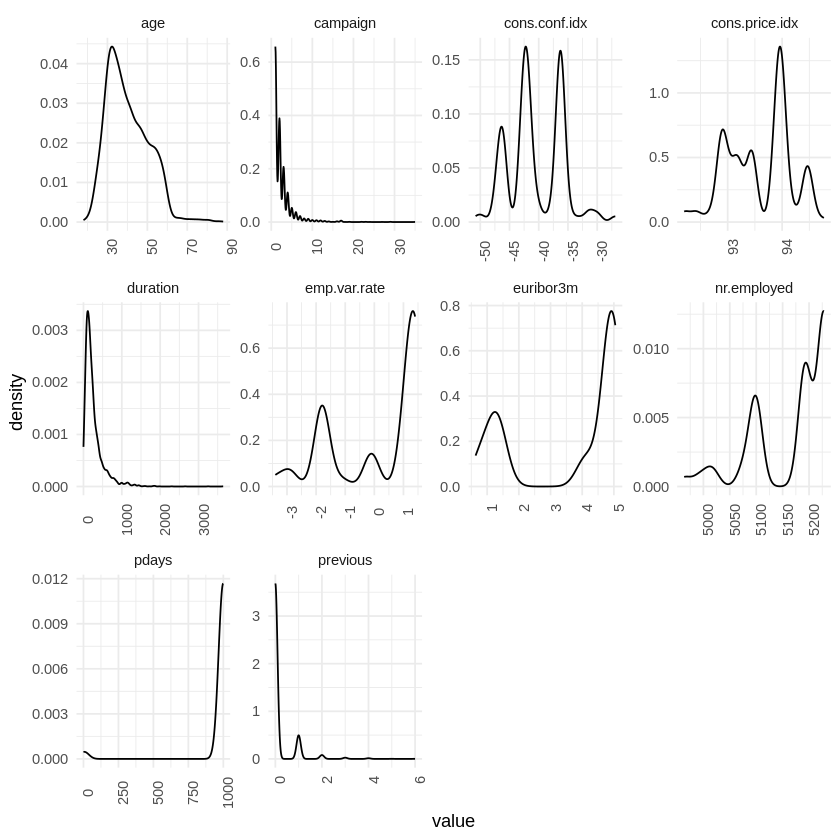

In [ ]:
# density plots
ggplot(num_marketing_long, aes(value)) +
  geom_density() +
  facet_wrap(~variable, scales = "free") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90))

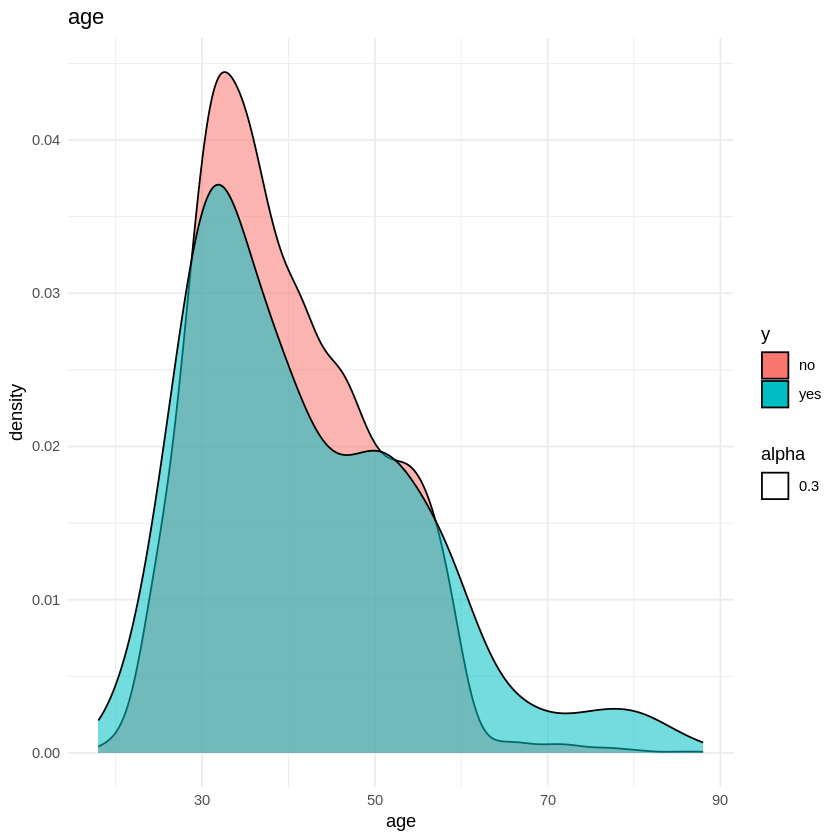

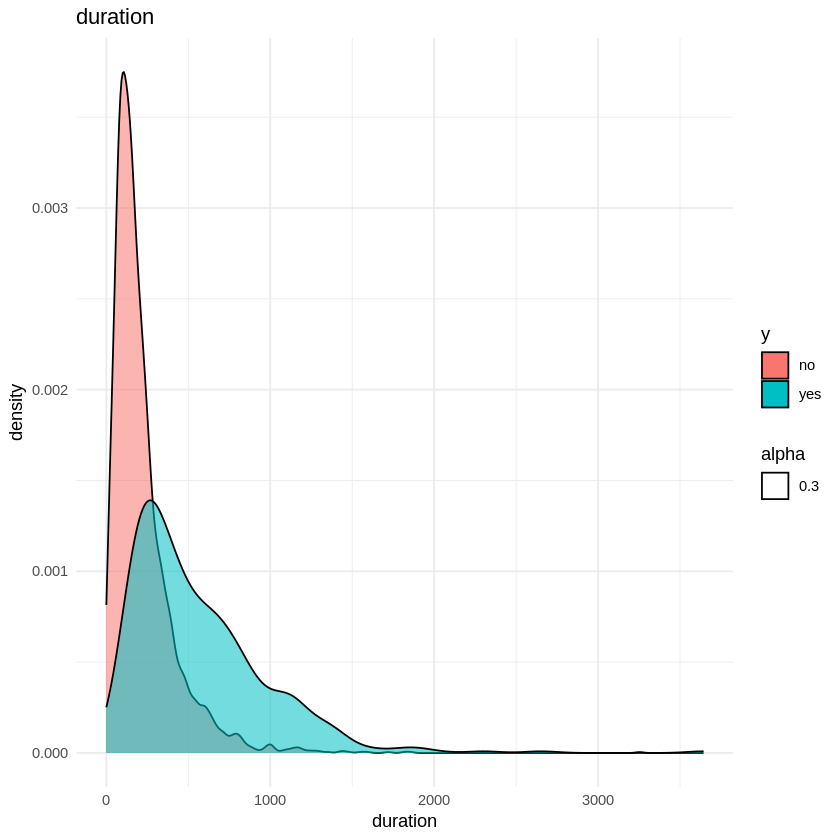

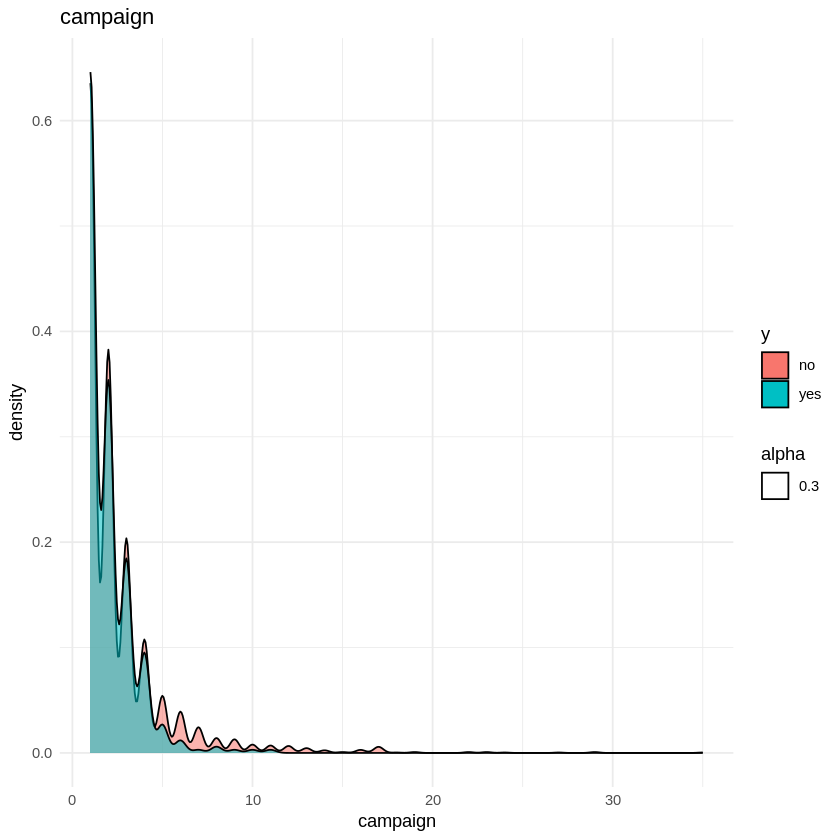

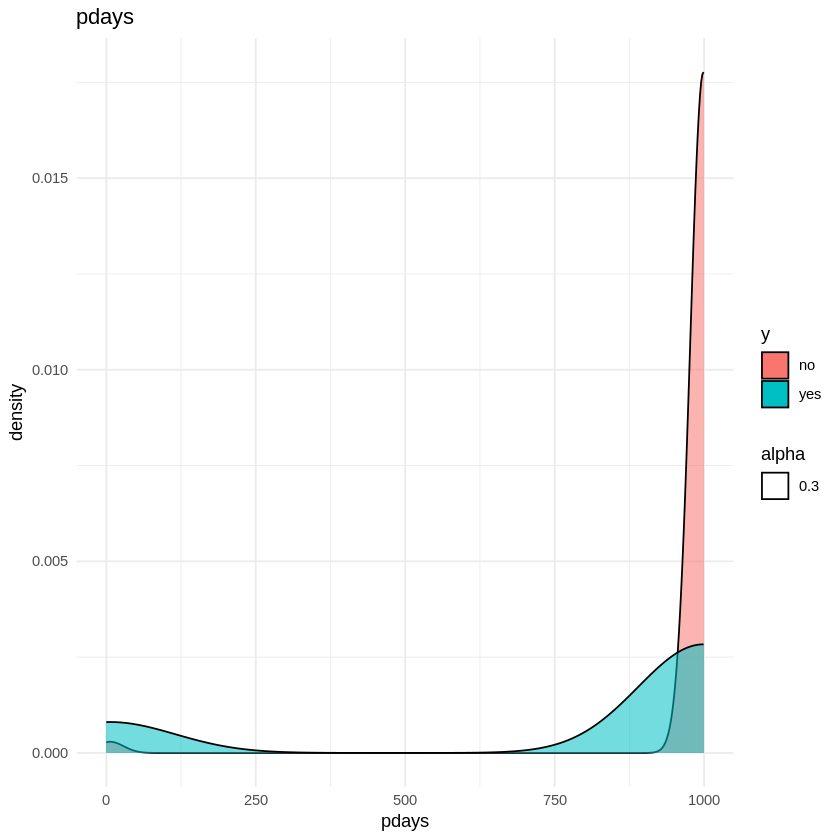

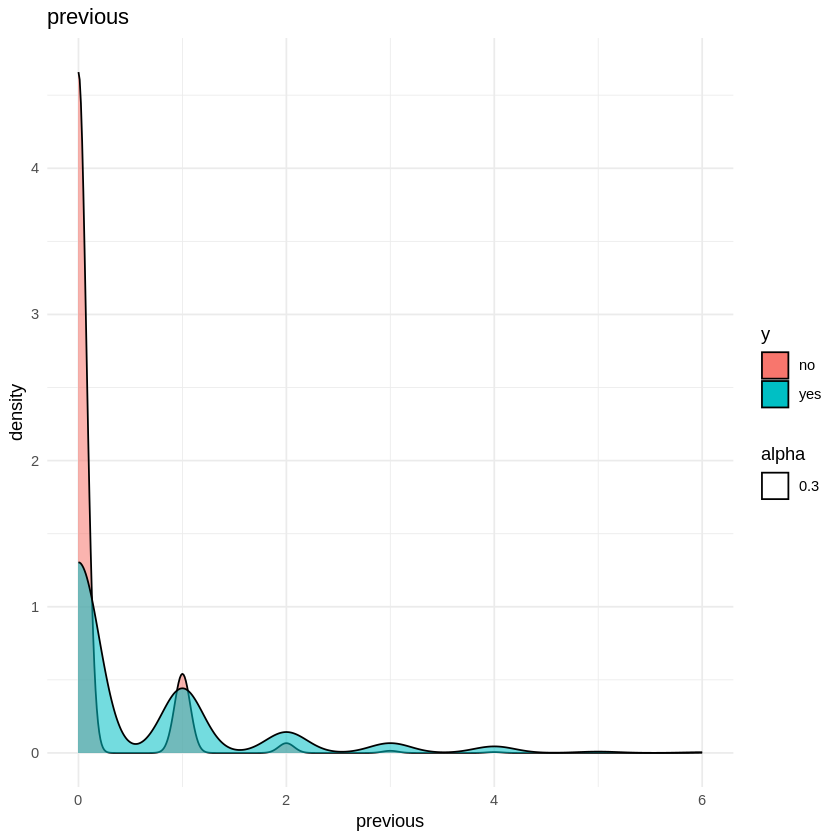

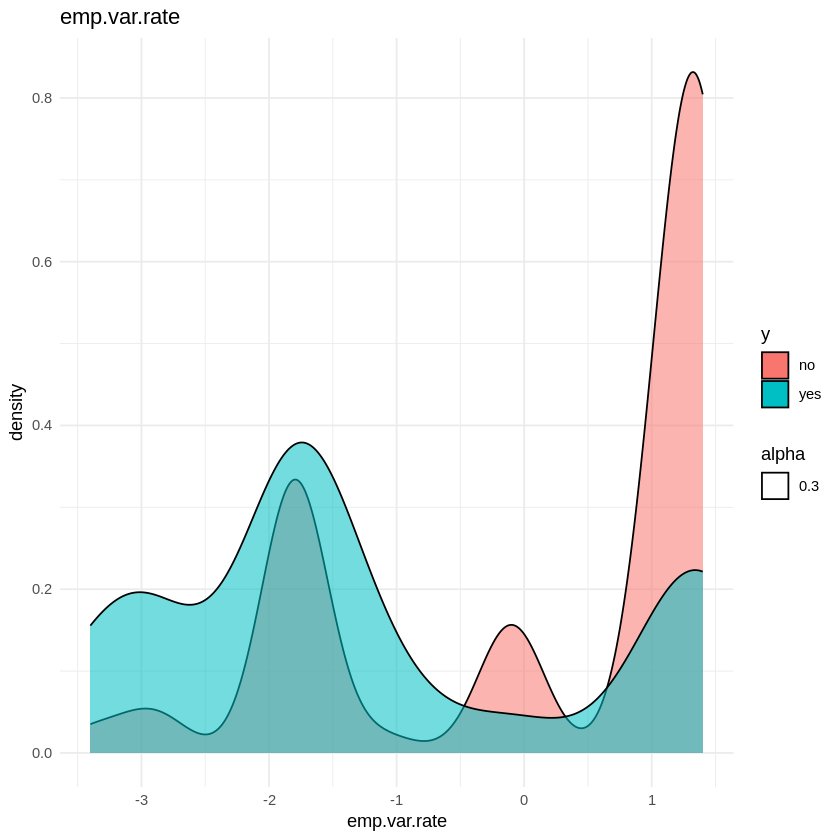

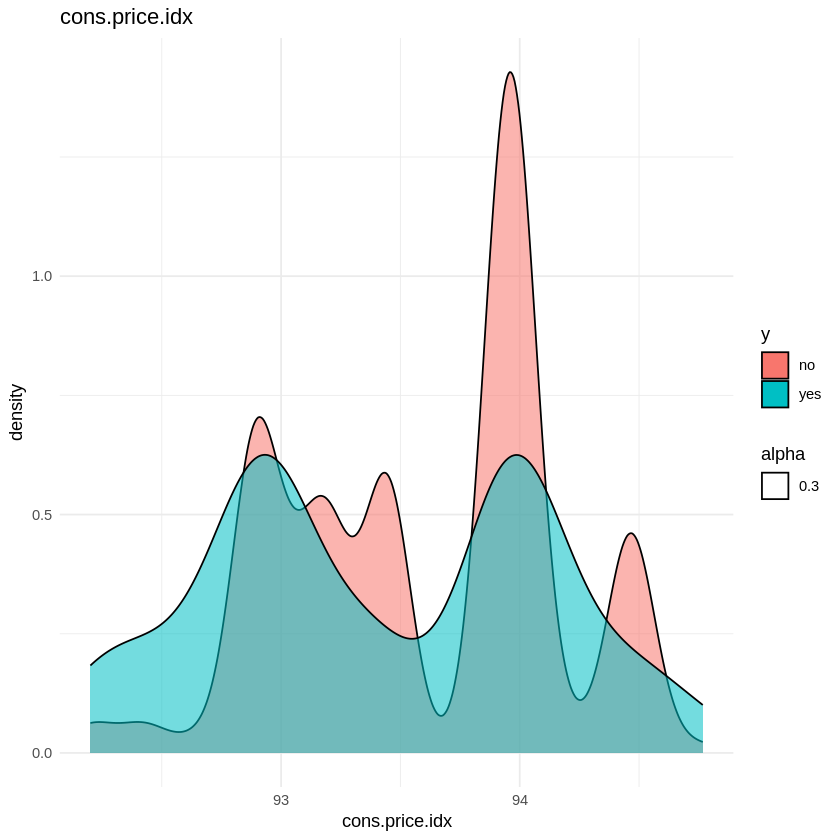

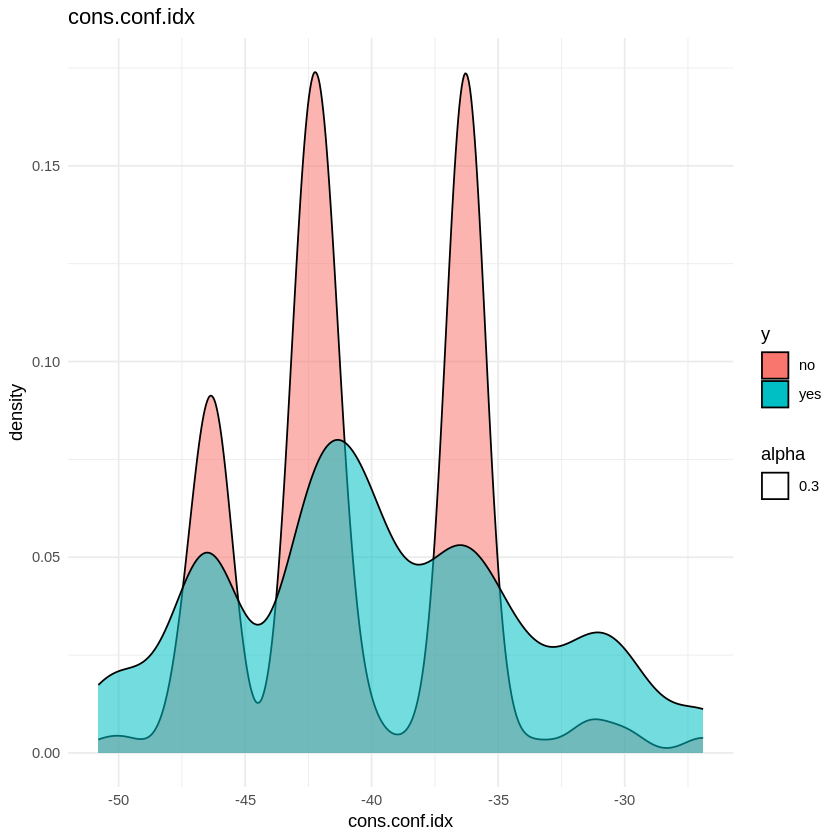

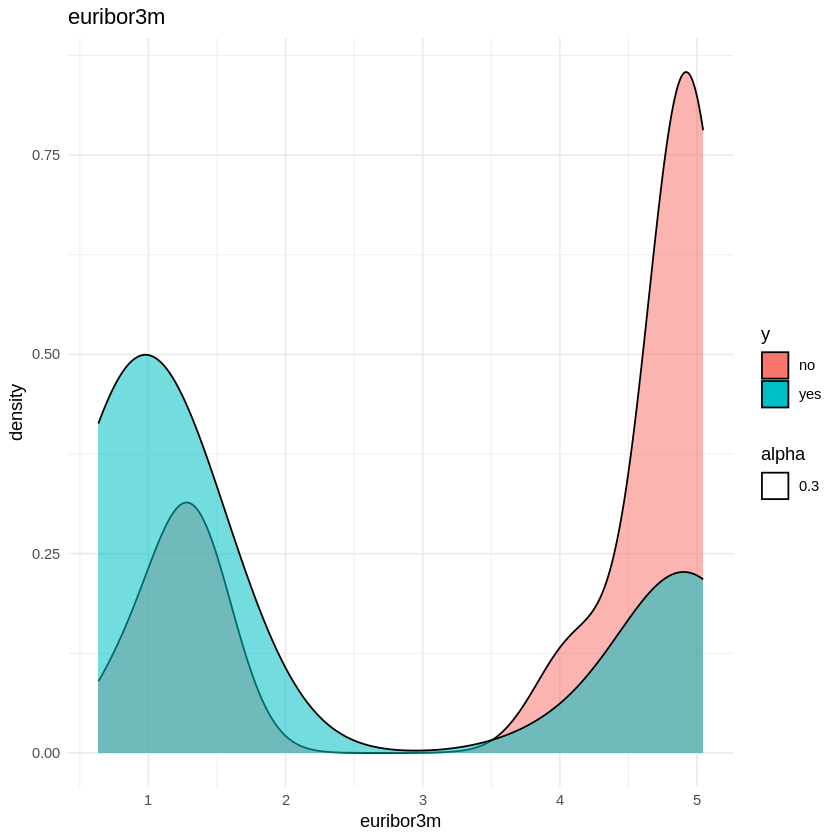

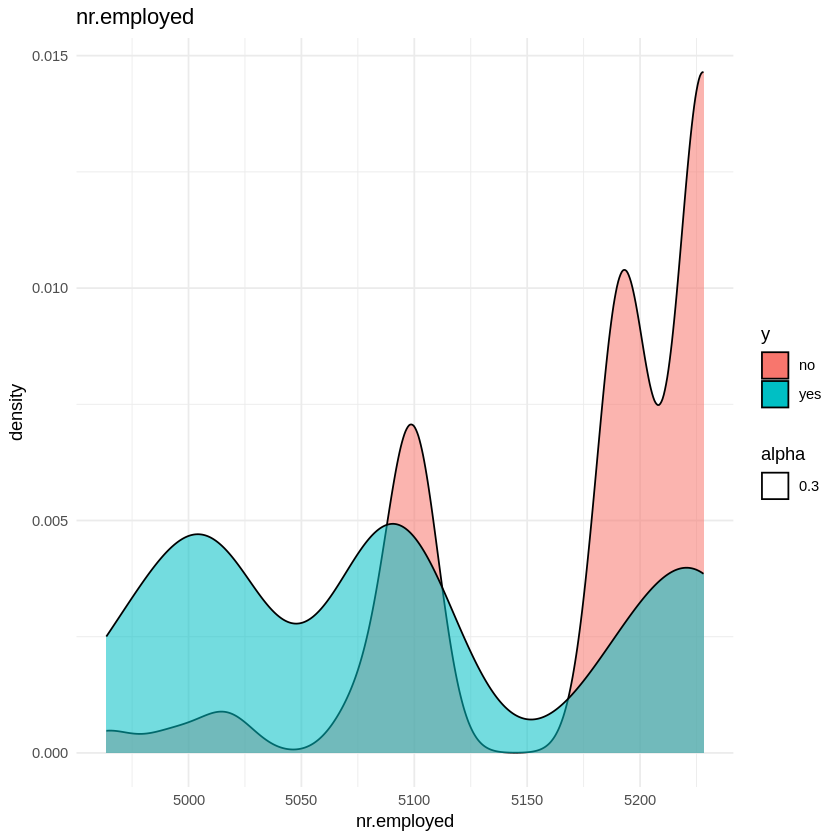

In [ ]:
# Check density plots vs target
for (var in num_var) {
  print(
    ggplot(marketing_data, aes_string(x = var)) +
      geom_density(aes(fill = y, alpha = 0.3)) +
      ggtitle(paste(var)) +
      theme_minimal()
  )
}

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


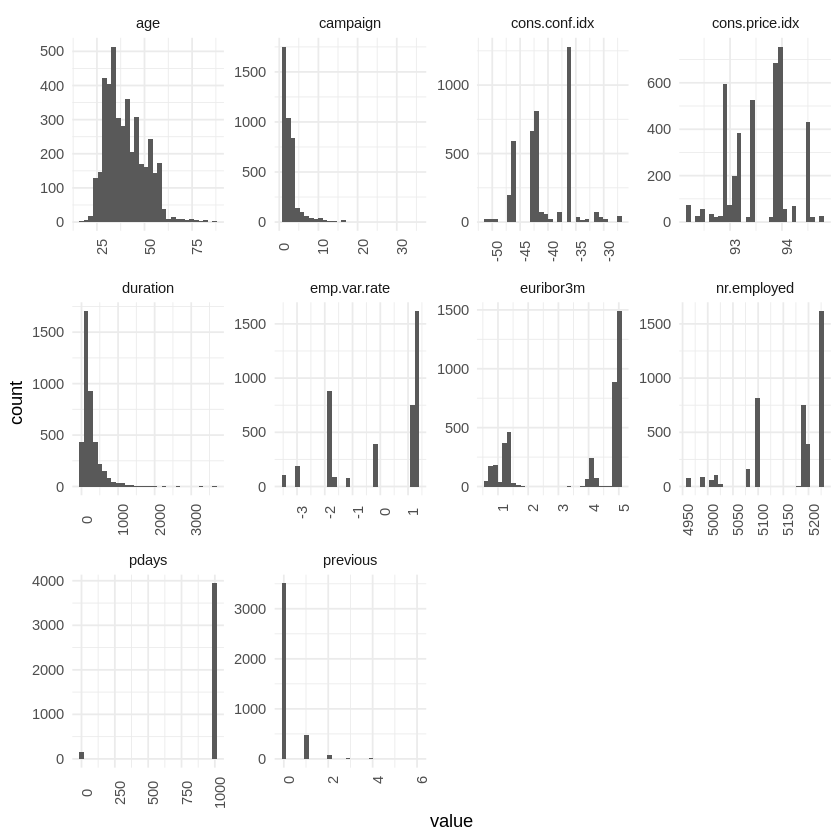

In [ ]:
# histograms
ggplot(num_marketing_long, aes(value)) +
  geom_histogram() +
  facet_wrap(~variable, scales = "free") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90))

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


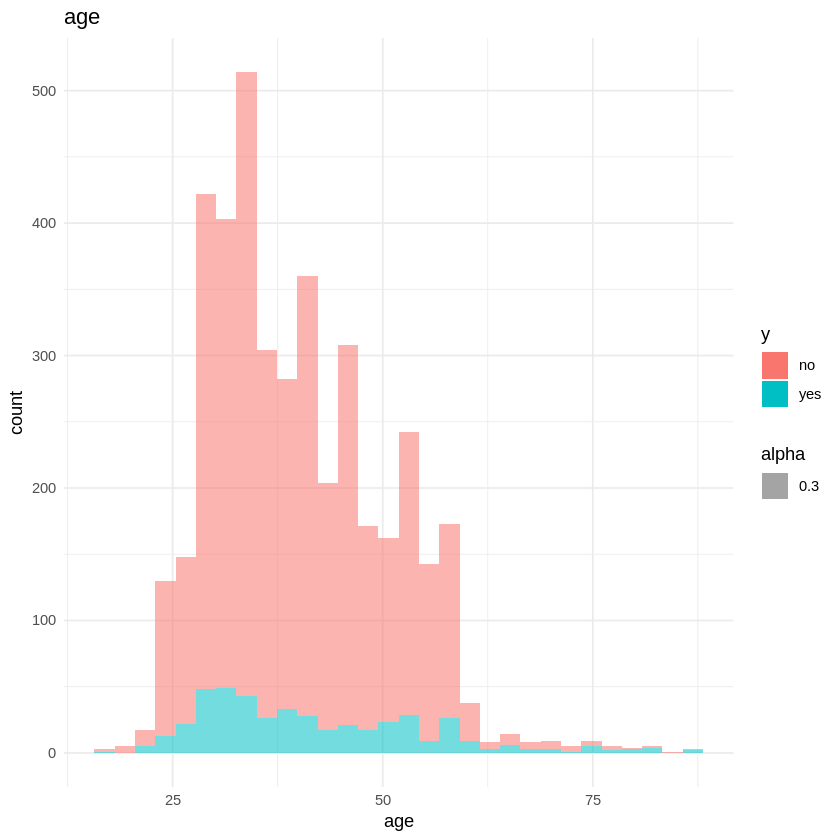

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


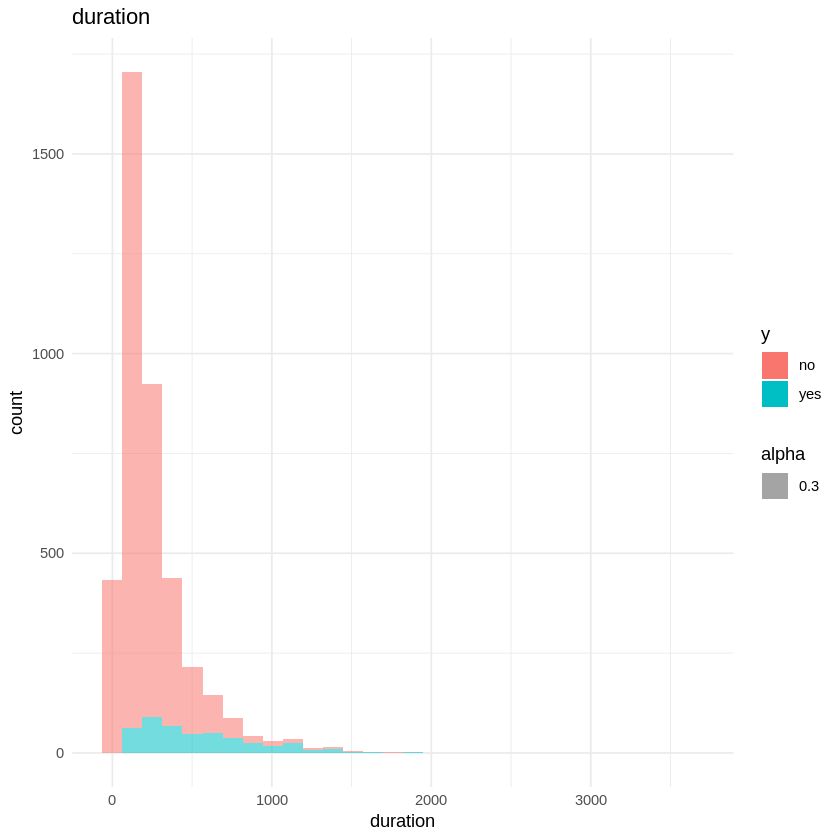

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


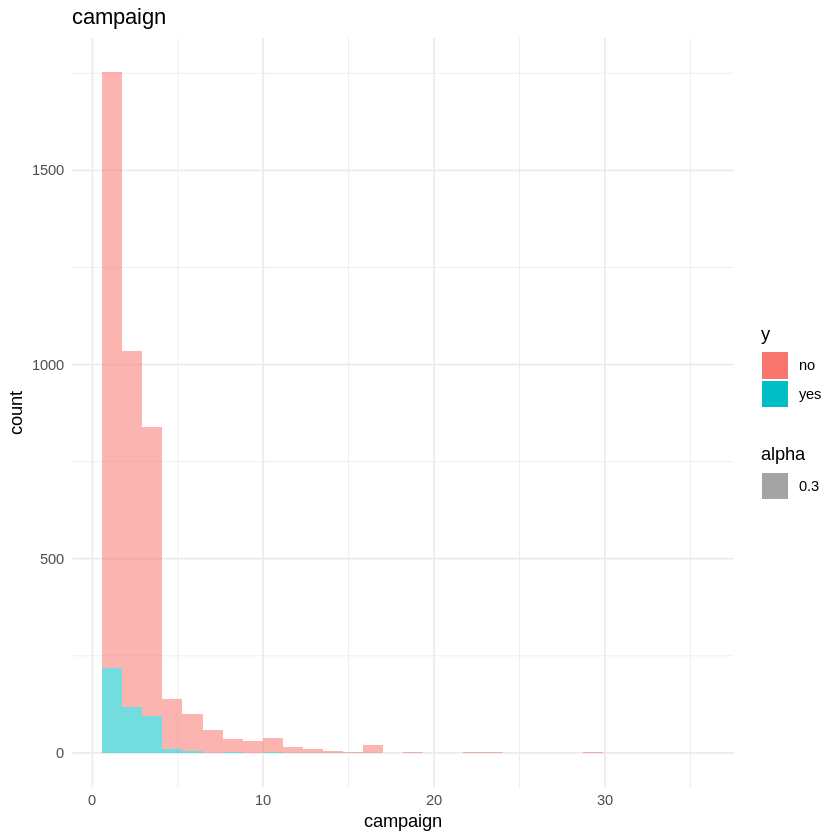

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


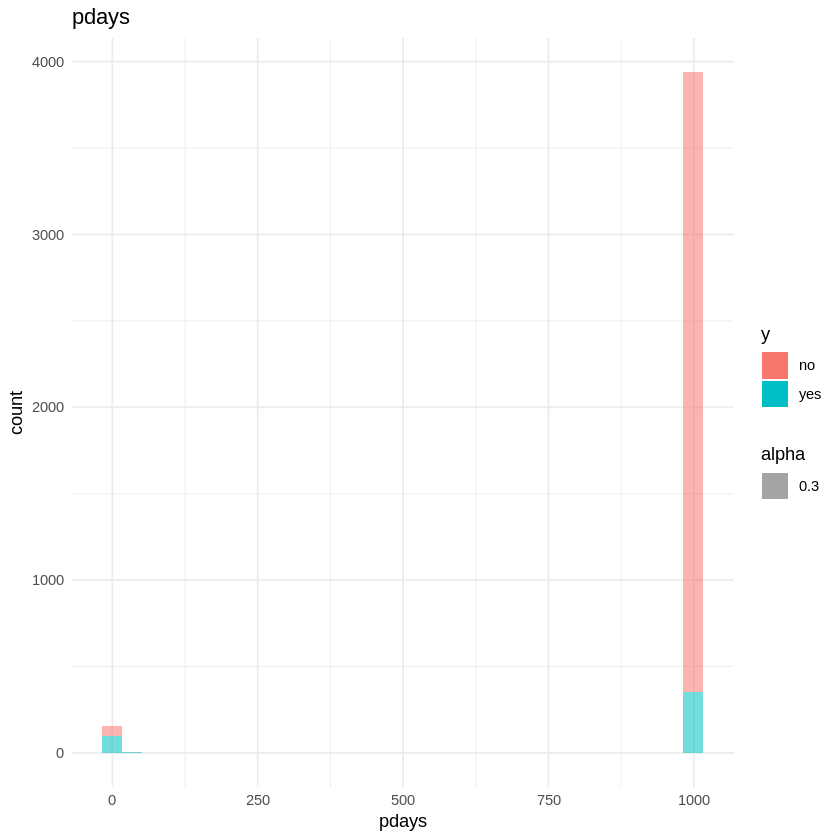

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


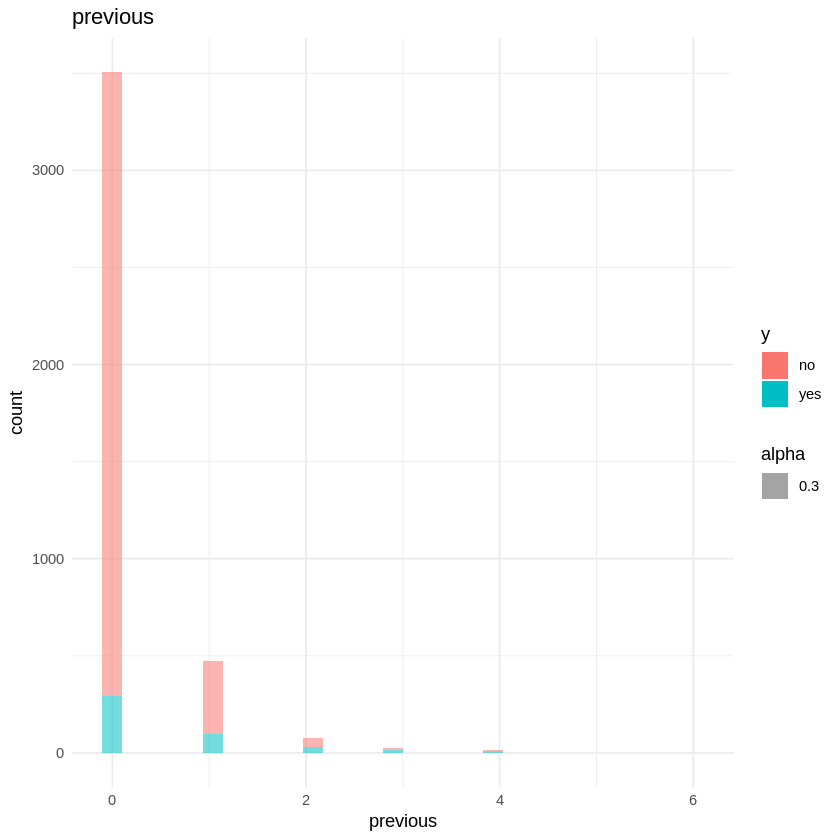

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


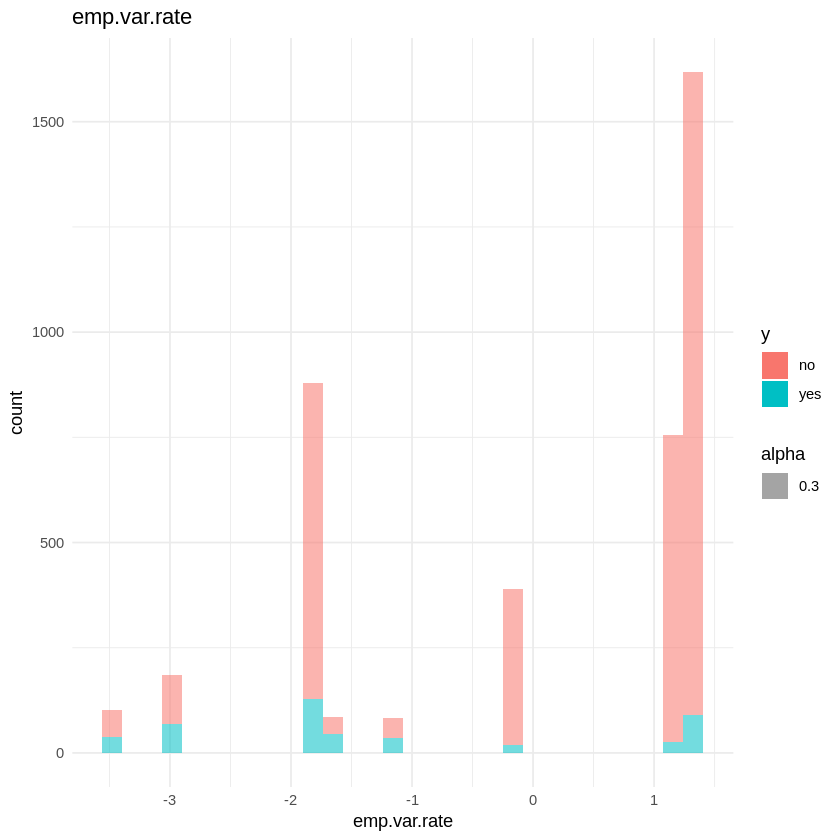

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


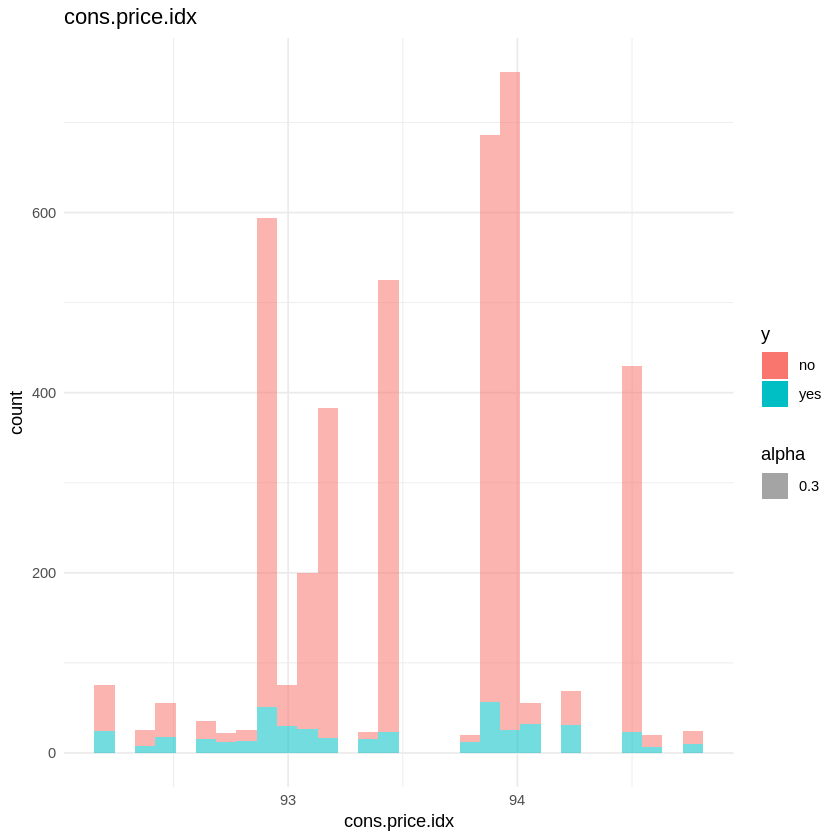

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


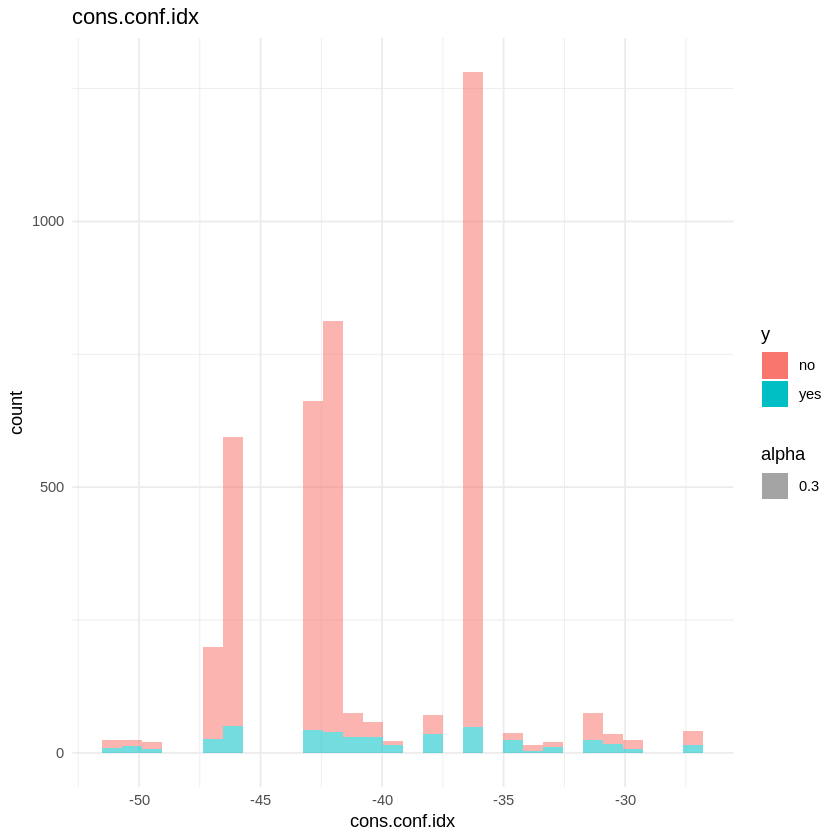

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


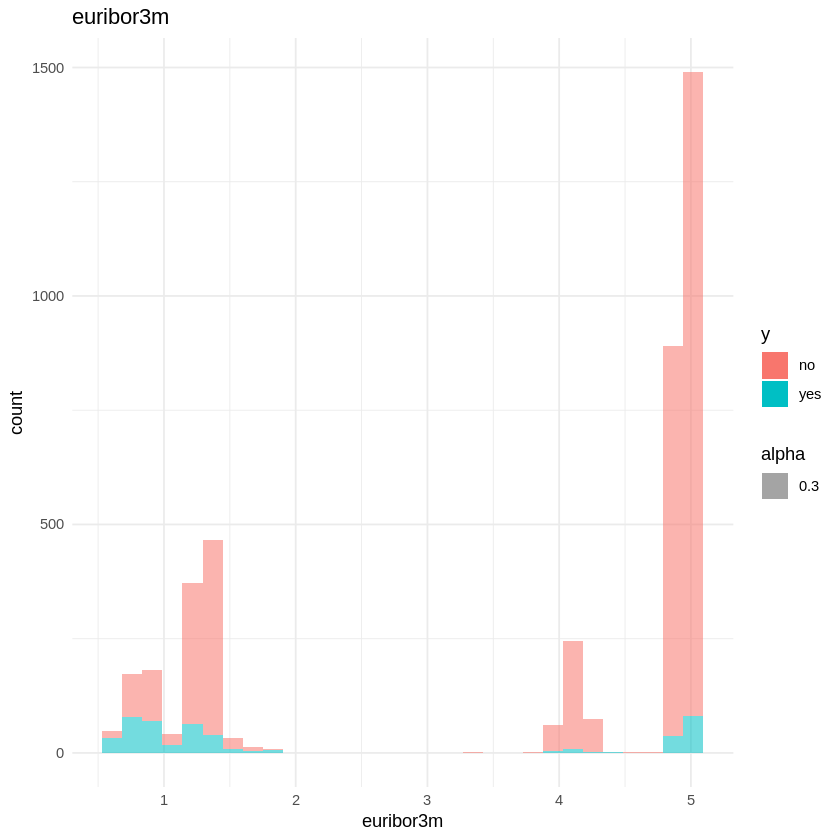

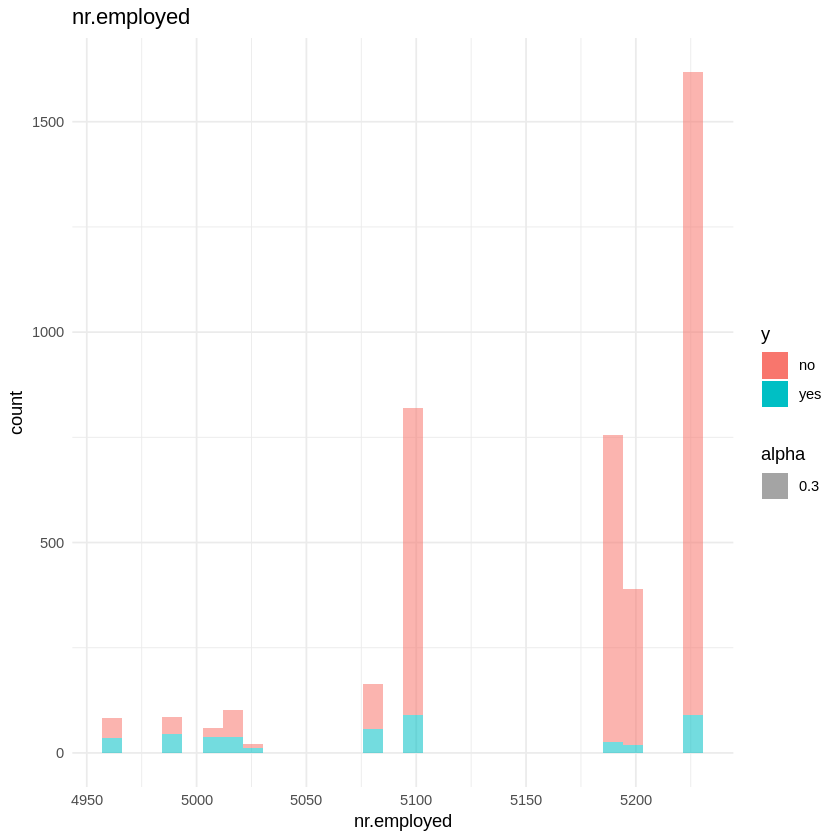

In [ ]:
# Check histogram plots vs target
for (var in num_var) {
  print(
    ggplot(marketing_data, aes_string(x = var)) +
      geom_histogram(aes(fill = y, alpha = 0.3)) +
      ggtitle(paste(var)) +
      theme_minimal()
  )
}

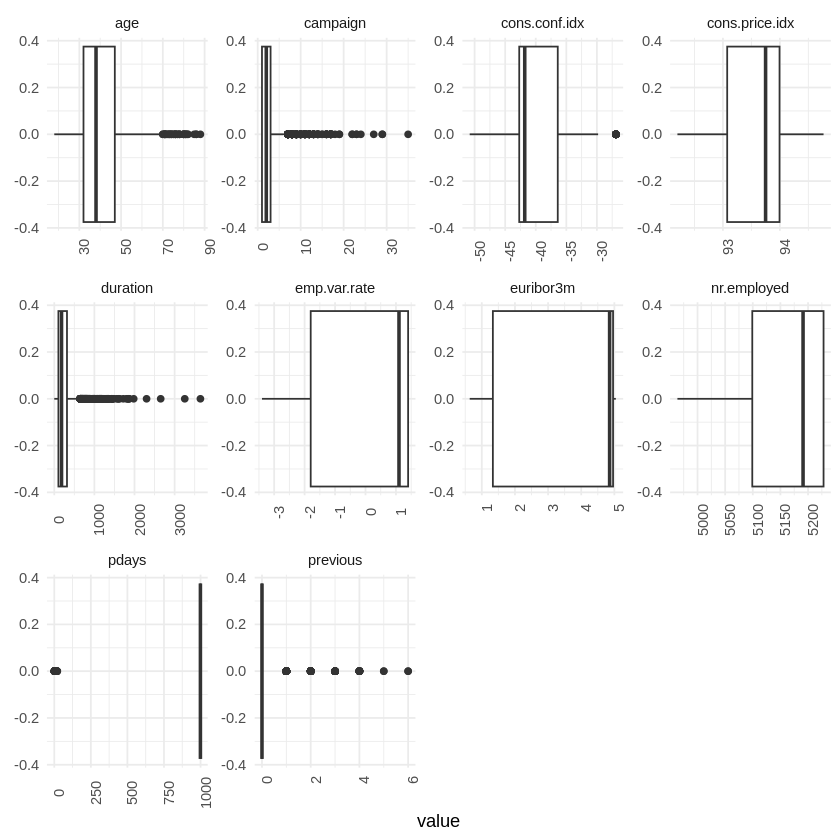

In [ ]:
# boxplots
ggplot(num_marketing_long, aes(value)) +
  geom_boxplot() +
  facet_wrap(~variable, scales = "free") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90))

previous, pdays, duration and campaign have alot of outliers.

In [ ]:
num_var

[1] "age"            "duration"       "campaign"       "pdays"         
 [5] "previous"       "emp.var.rate"   "cons.price.idx" "cons.conf.idx" 
 [9] "euribor3m"      "nr.employed"

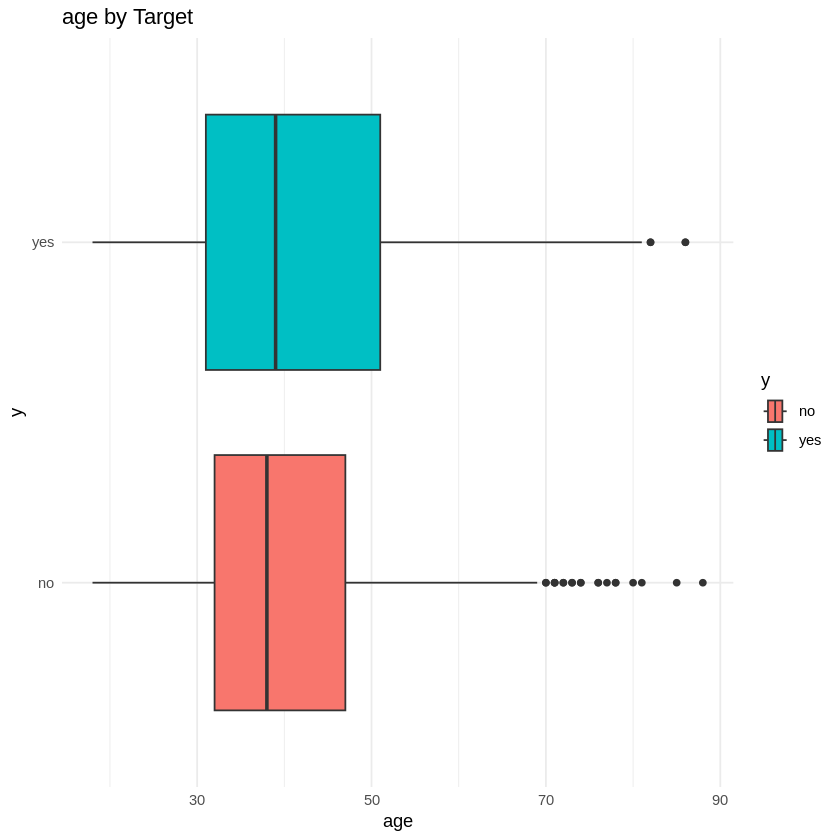

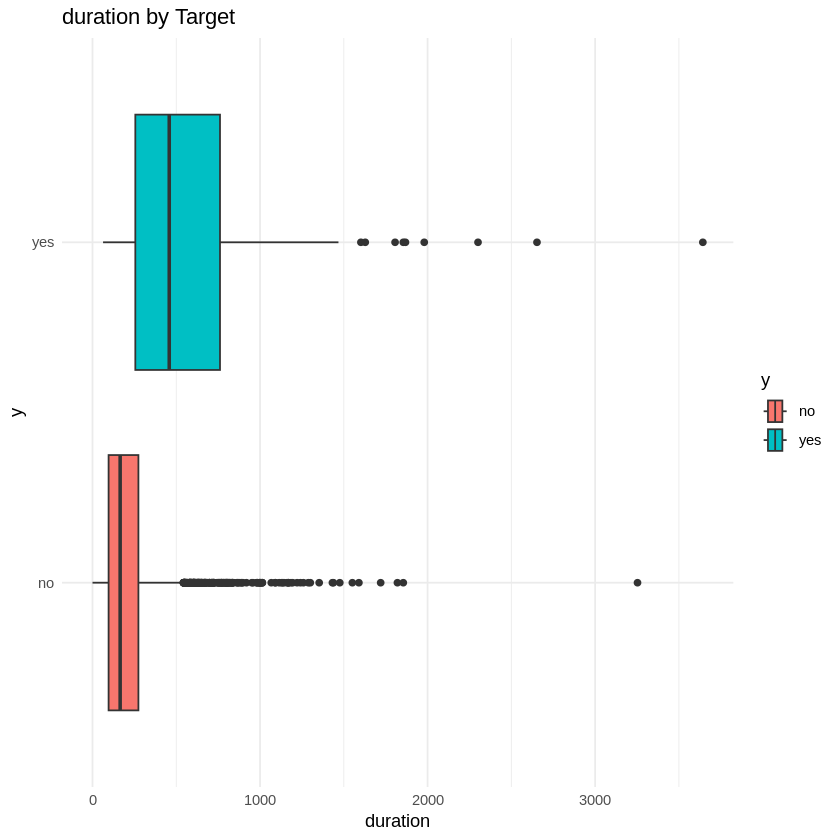

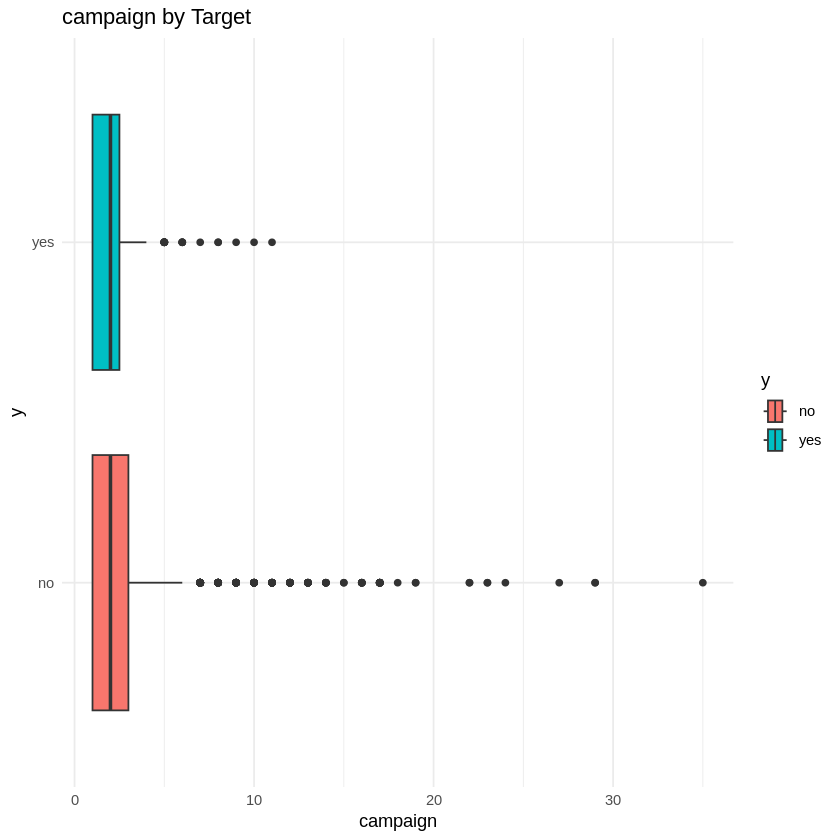

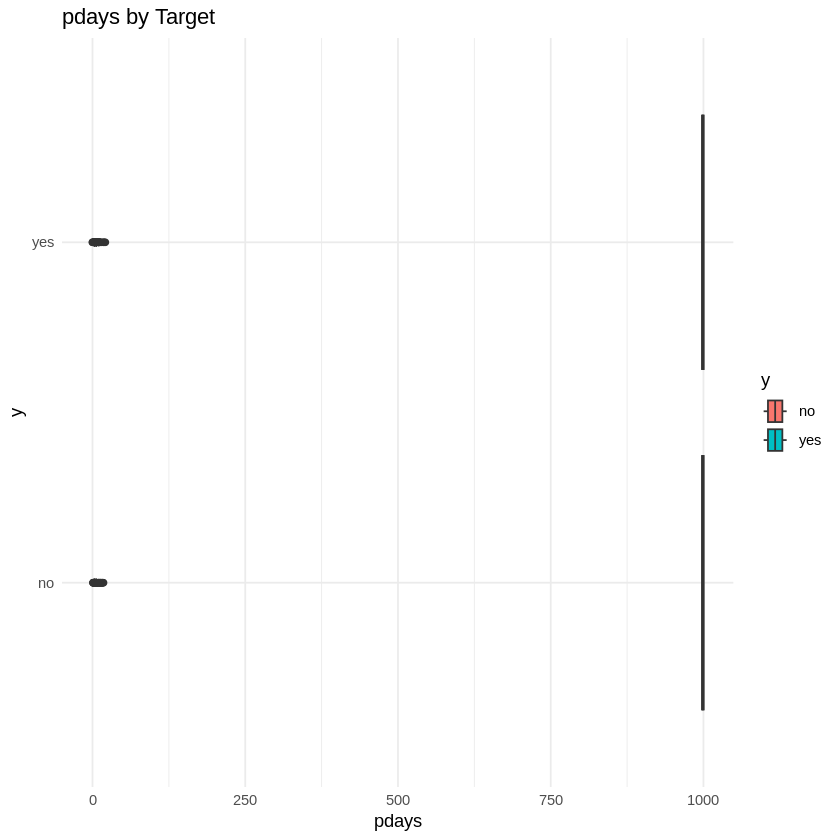

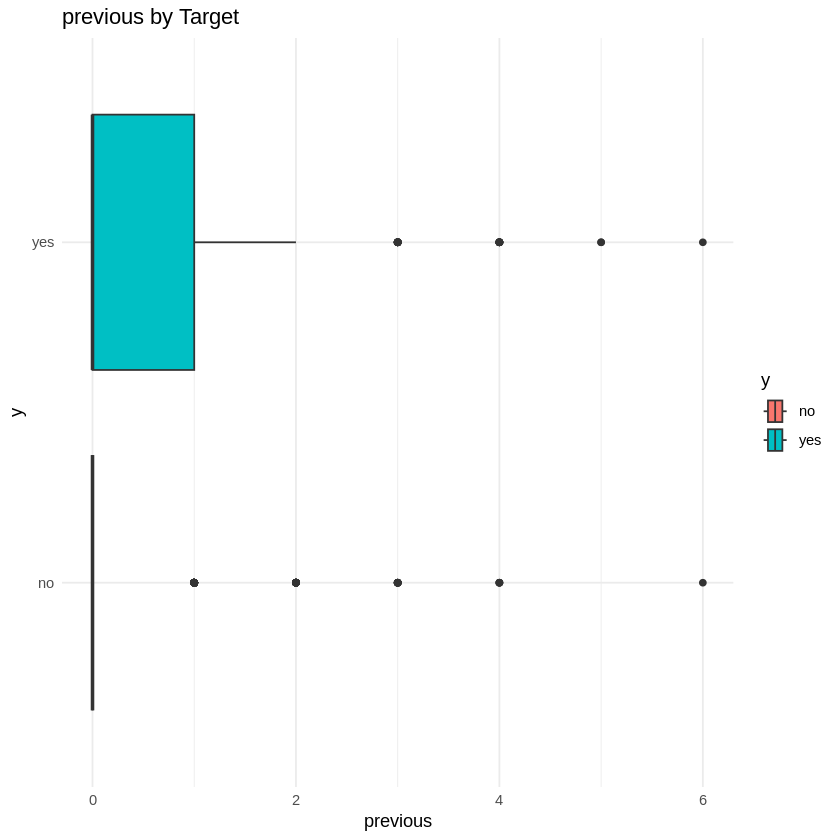

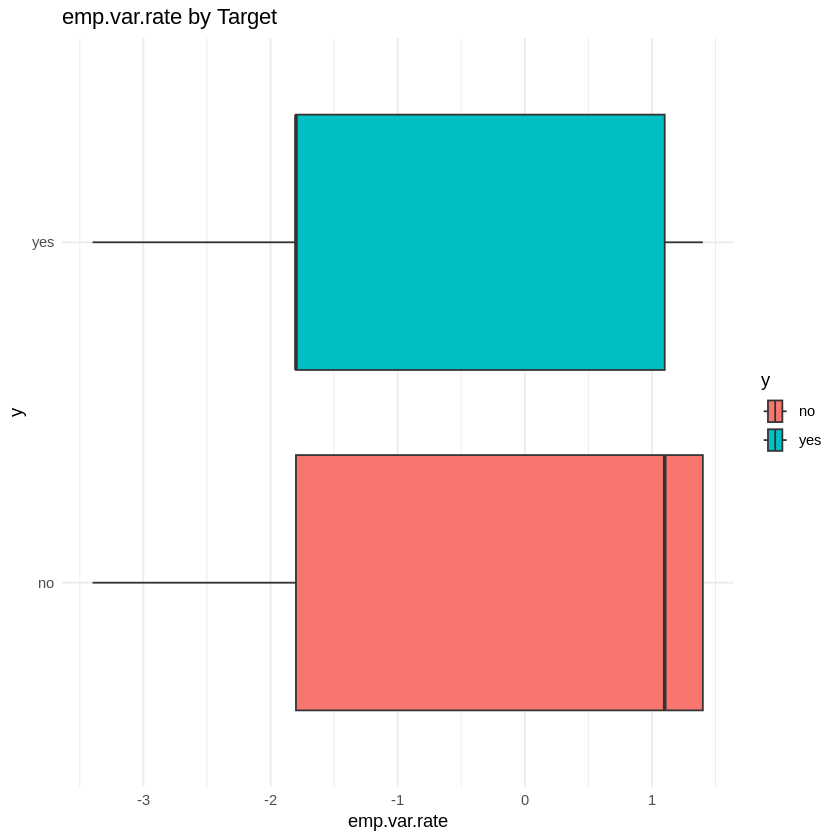

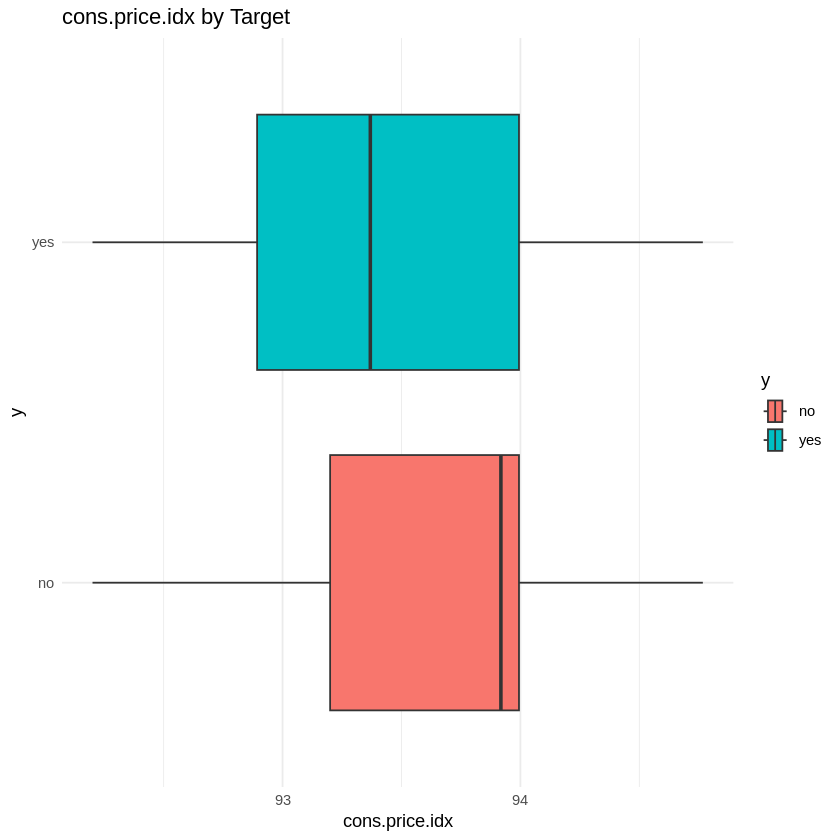

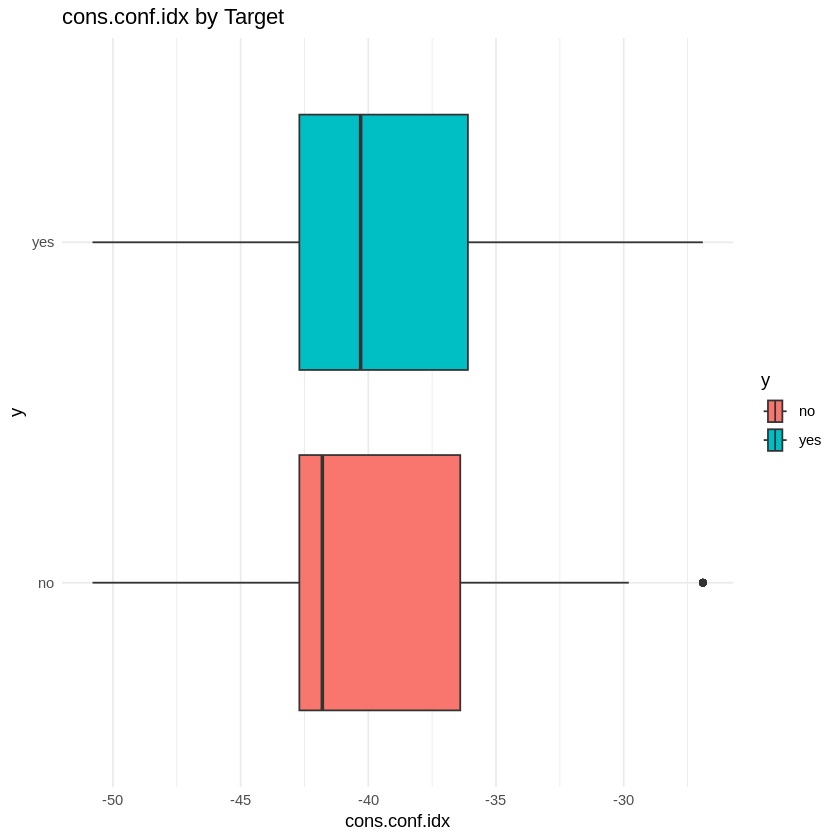

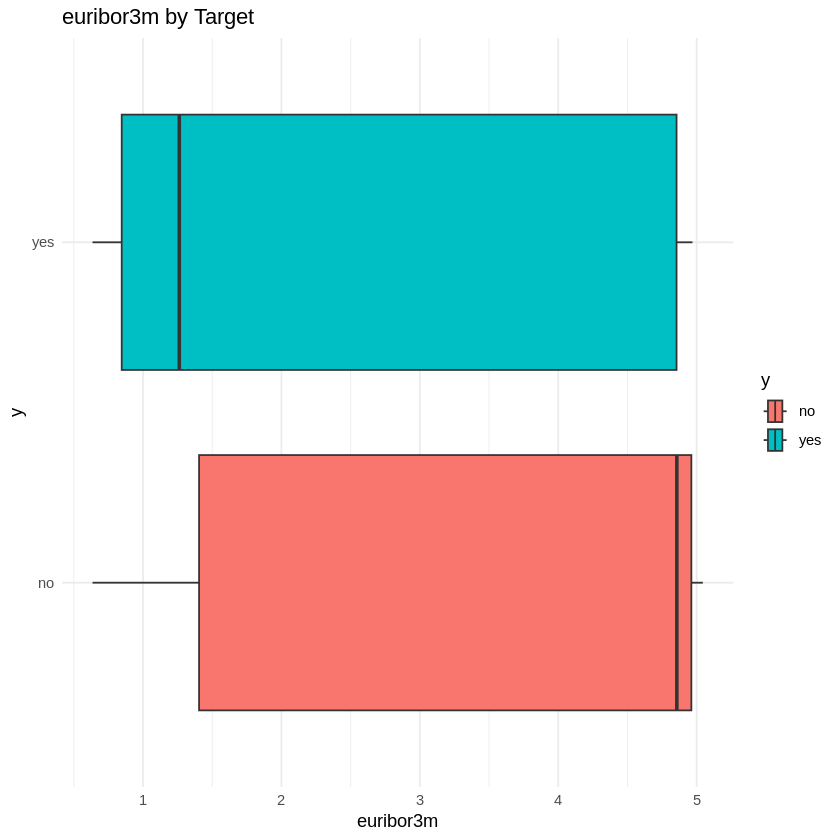

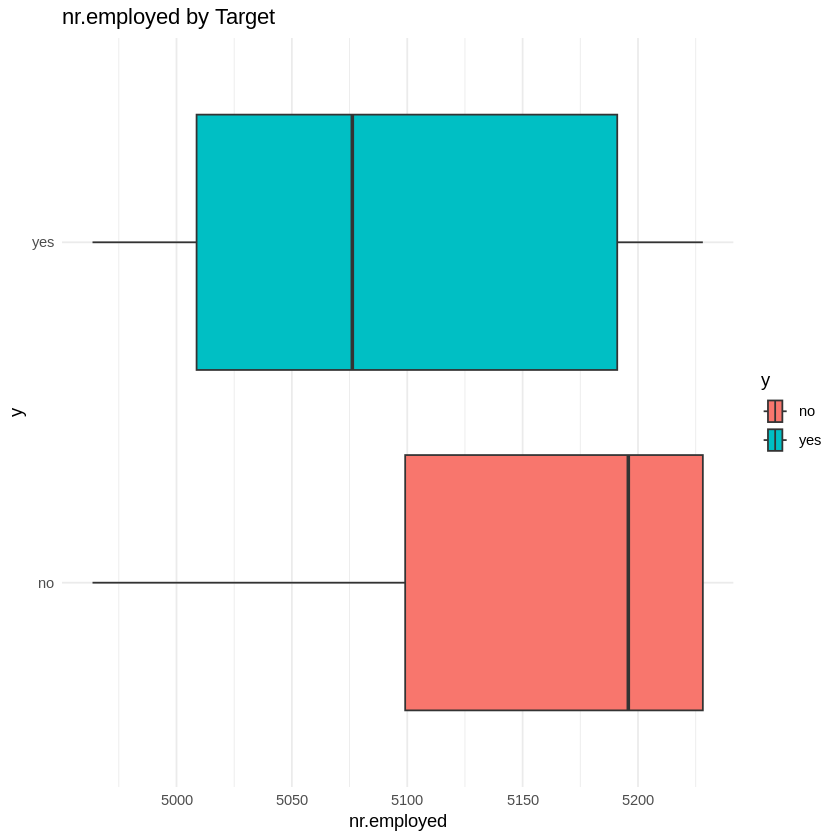

In [ ]:
# Check numerical variable vs target
for (var in num_var) {
  print(
    ggplot(marketing_data, aes_string(x = var, y = "y")) +
      geom_boxplot(aes(fill = y)) +
      ggtitle(paste(var , "by Target")) +
      theme_minimal()
  )
}

Invesigating median:
* **duration** indicates that the median duration of the call that resulted in no is smaller than the lower quartile of the duration that resulted in yes. this indicates a relationship between call duration and the result of a sale.

* **previous**- look at IQR

* **emp.var.rate**, **cons.price.idx**, **euribor3m** and **nr.employed** all show the median of yes results being lower than for no.

investigating outliers:

* previous, pdays, campaign and duration have alot of outliers.

investigate dispersion and skewness.

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



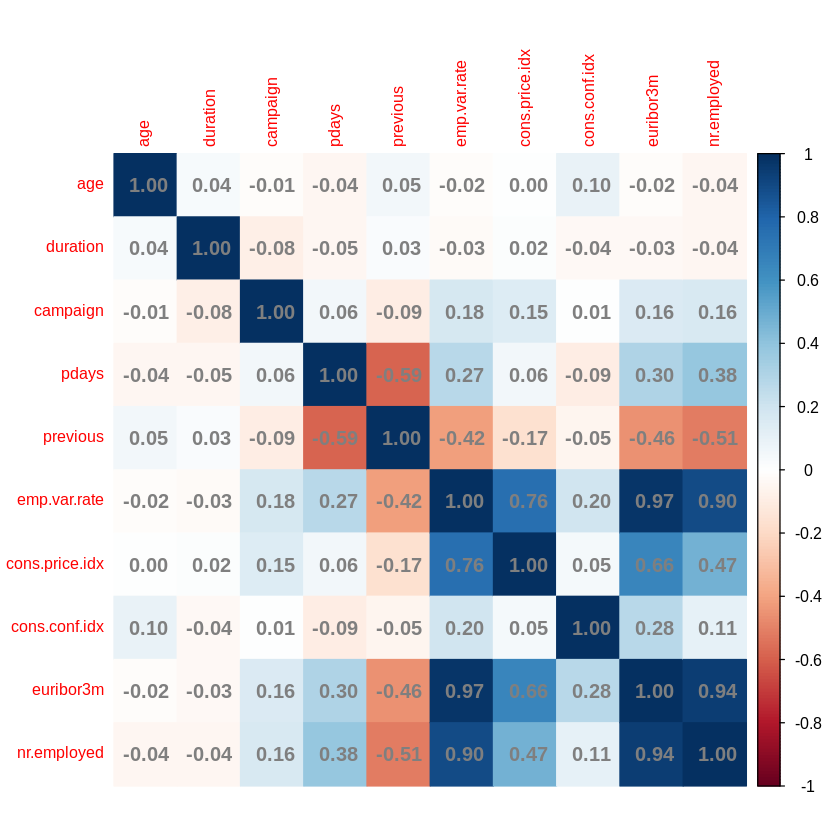

In [ ]:
# Correlation matrix
cor_matrix <- cor(num_marketing_data, use = "complete.obs")

# Heatmap
install.packages("corrplot")
library(corrplot)
cor_mtx_num <- corrplot(cor_matrix, method = "color", addCoef.col = "grey50", tl.cex = 0.8)

It looks like these variables are correlated:

* **pdays** and **previous**

* **emp.var.rate** with **nr.employed**, **cons.price.idx** and **euribor3m**

* **euribor3m** with **emp.var.rate** and **nr.employed**


### Investigating categorical variables

In [ ]:
# get categorical data into format for faceted plot
fac_marketing_long <- pivot_longer(fac_marketing_data, cols = colnames(fac_marketing_data), names_to = "variable", values_to = "value" )
head(fac_marketing_long)

variable,value
<chr>,<fct>
job,blue-collar
marital,married
k,basic.9y
default,no
housing,yes
loan,no


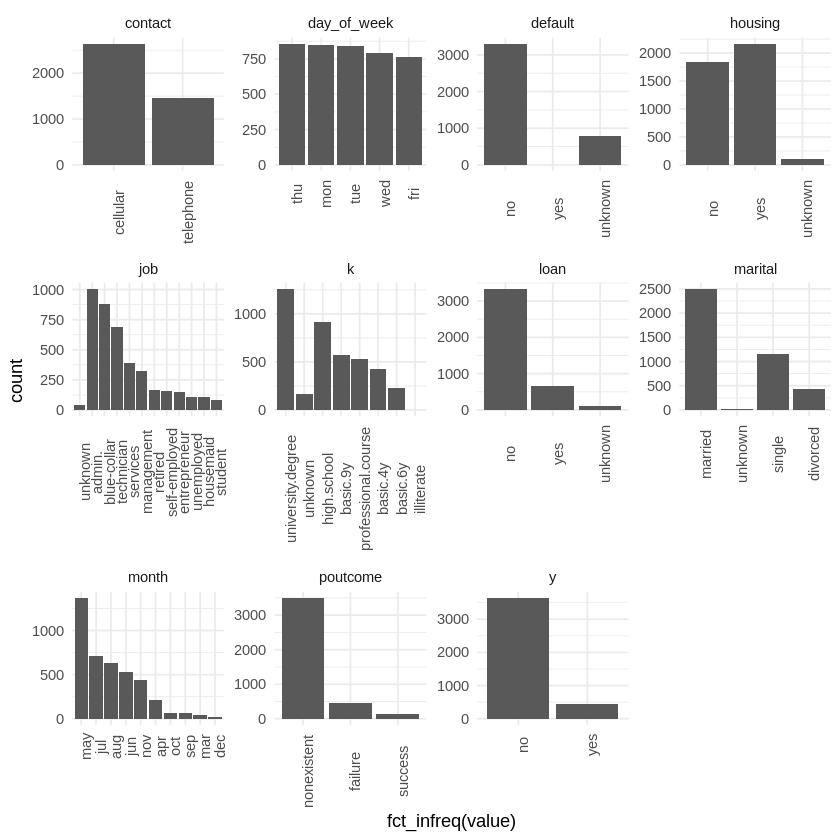

In [ ]:
# bar charts
ggplot(fac_marketing_long, aes(fct_infreq(value))) +
  geom_bar() +
  facet_wrap(~variable, scales = "free") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90))

The above bar plot indicated the imbalance with the target variable (y) well. It also indicates how default has an inobservable amount of yes observations and "unknowns" is substantial. For the other Categorical values with "unknown" the quantity is miniscule.

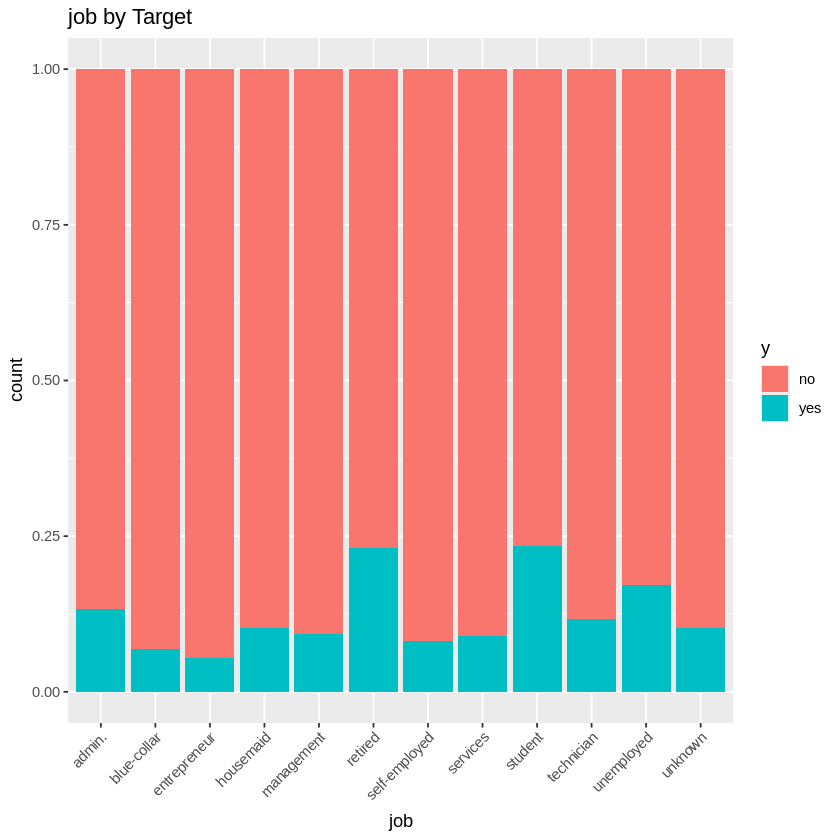

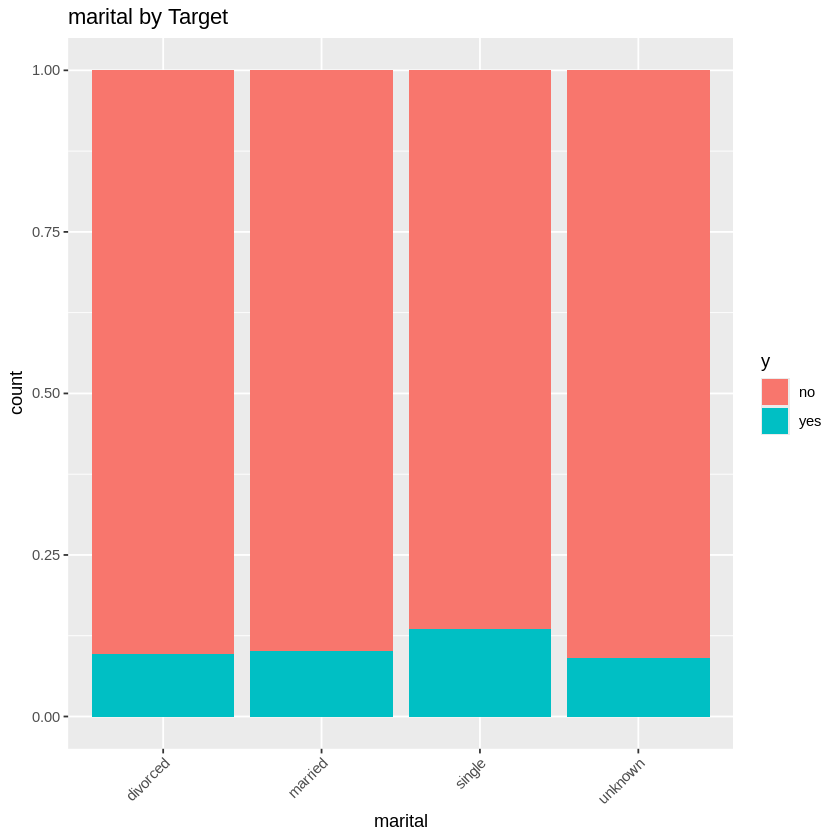

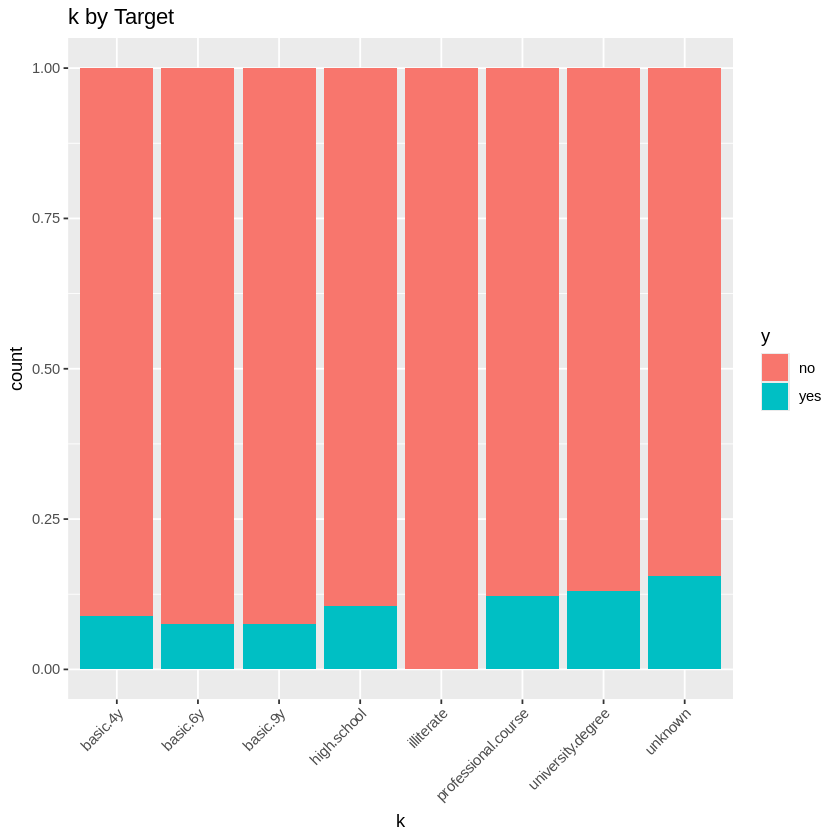

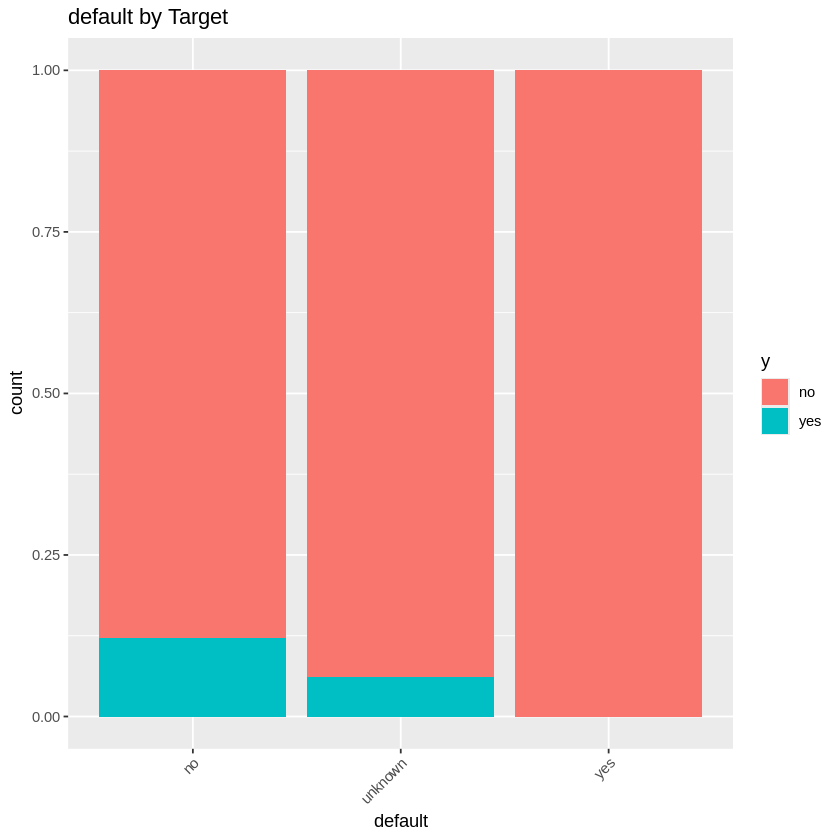

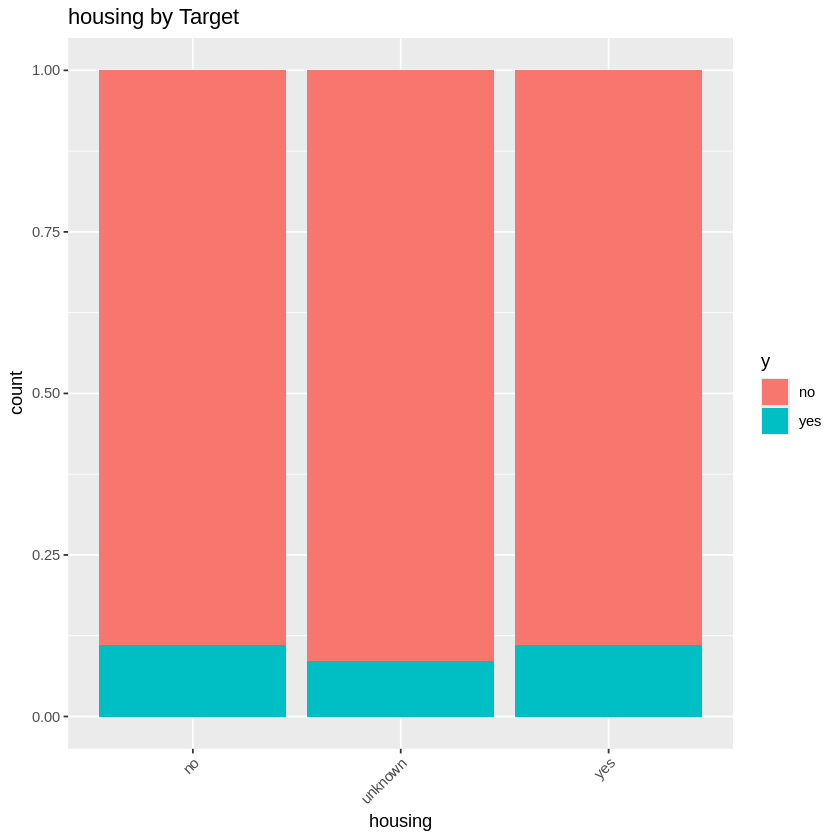

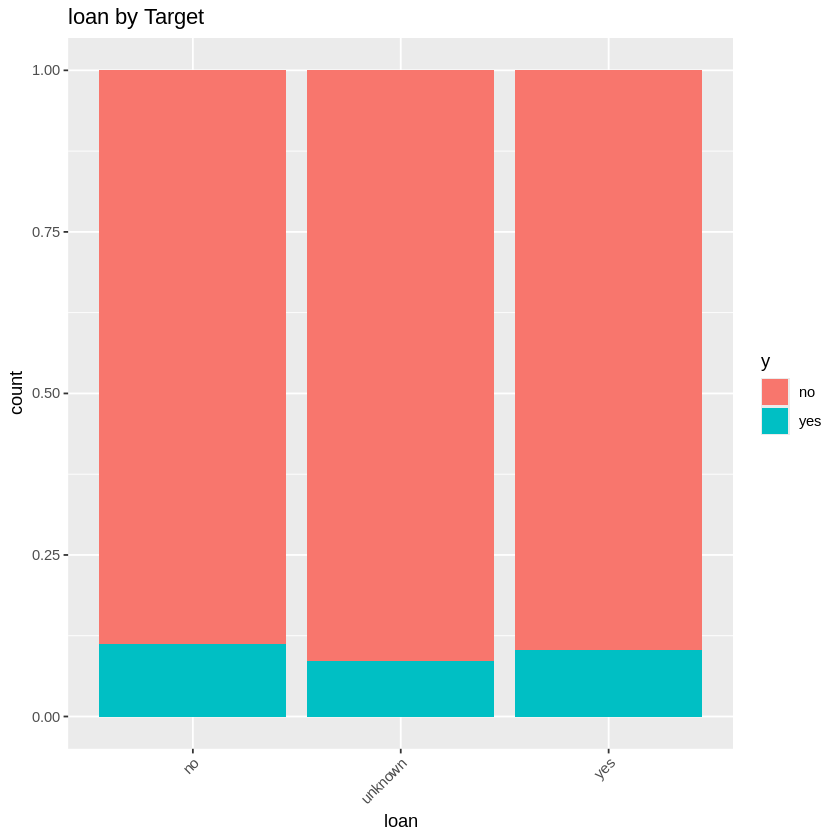

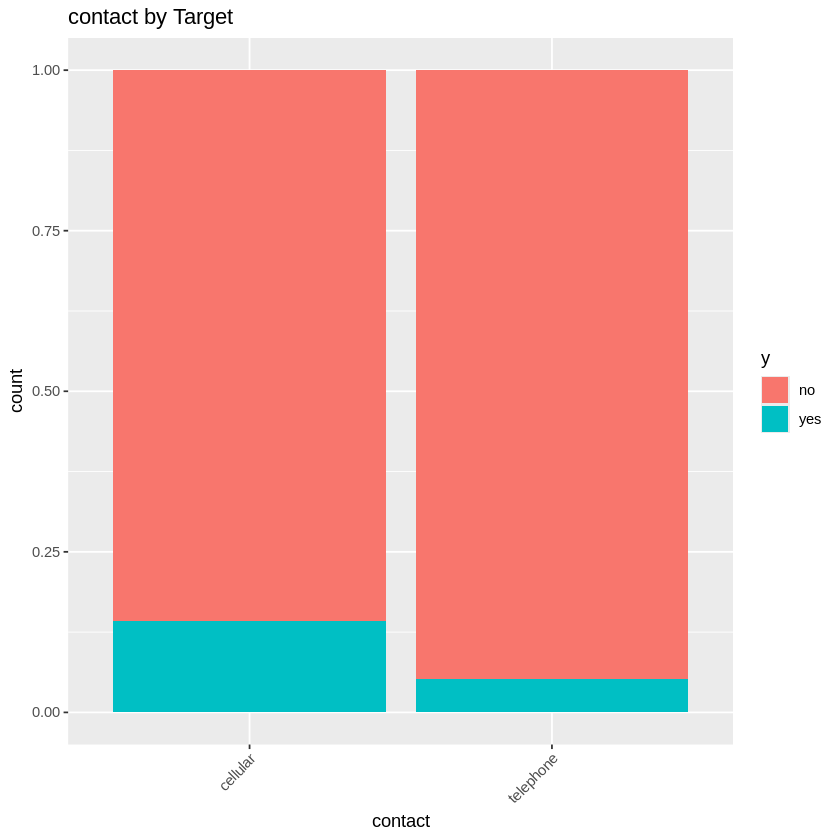

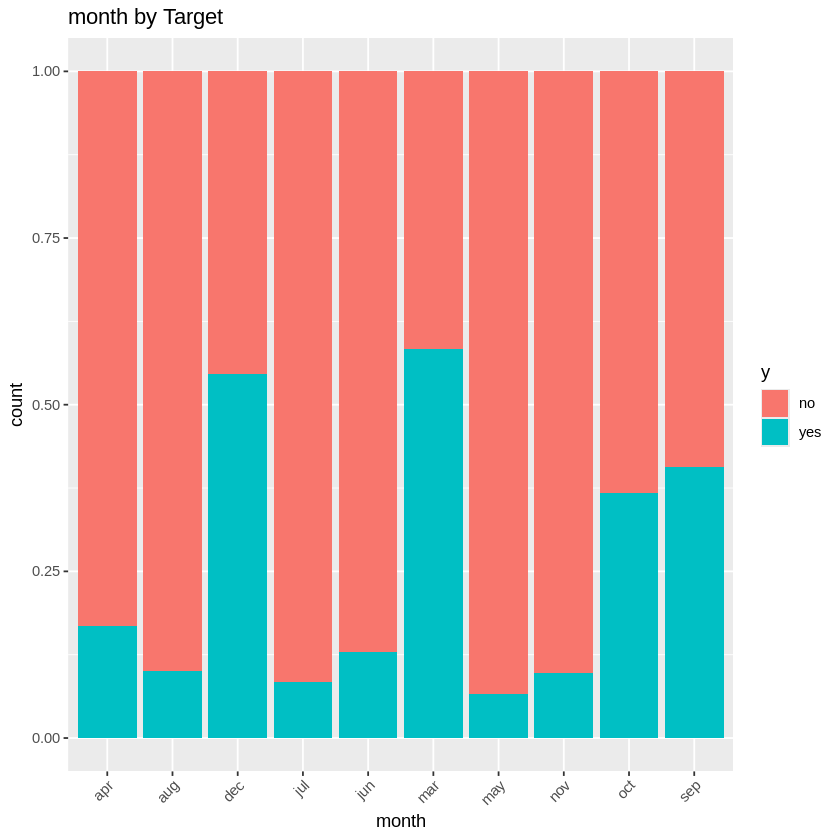

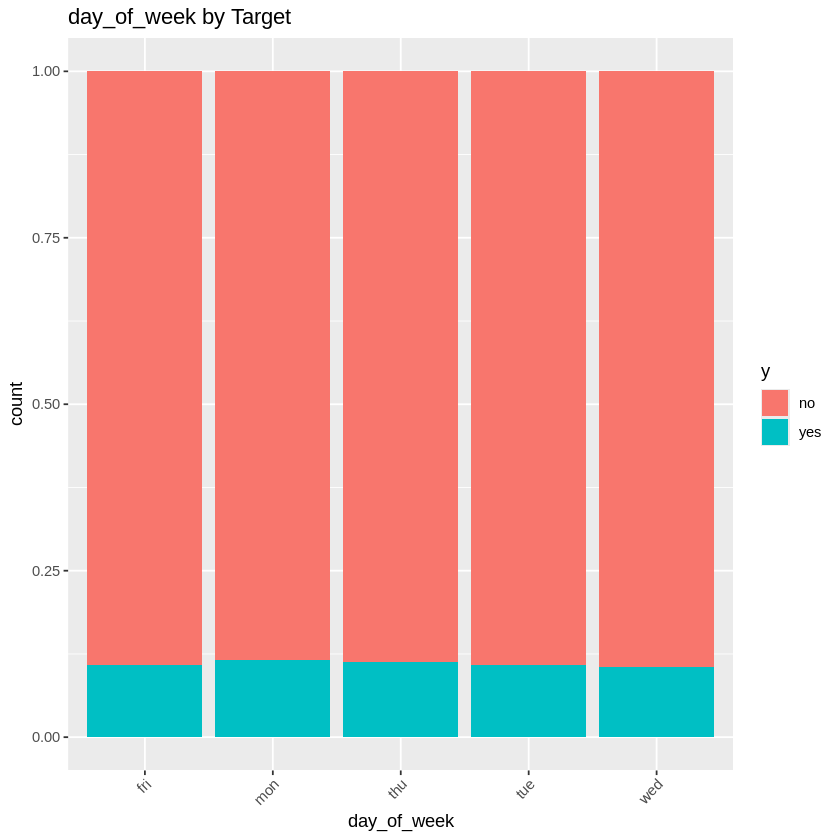

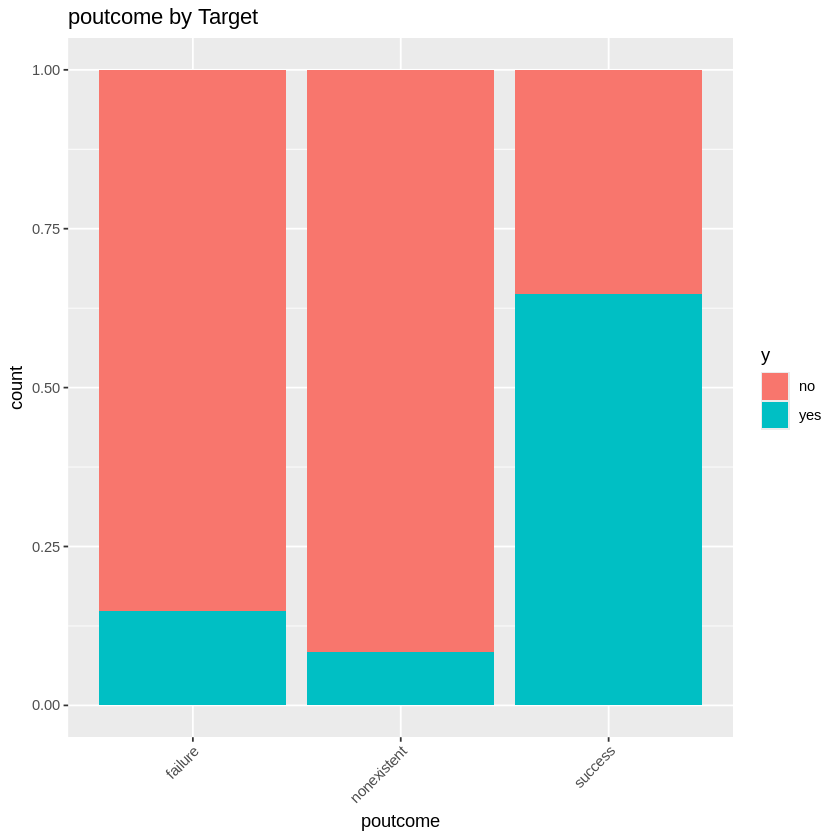

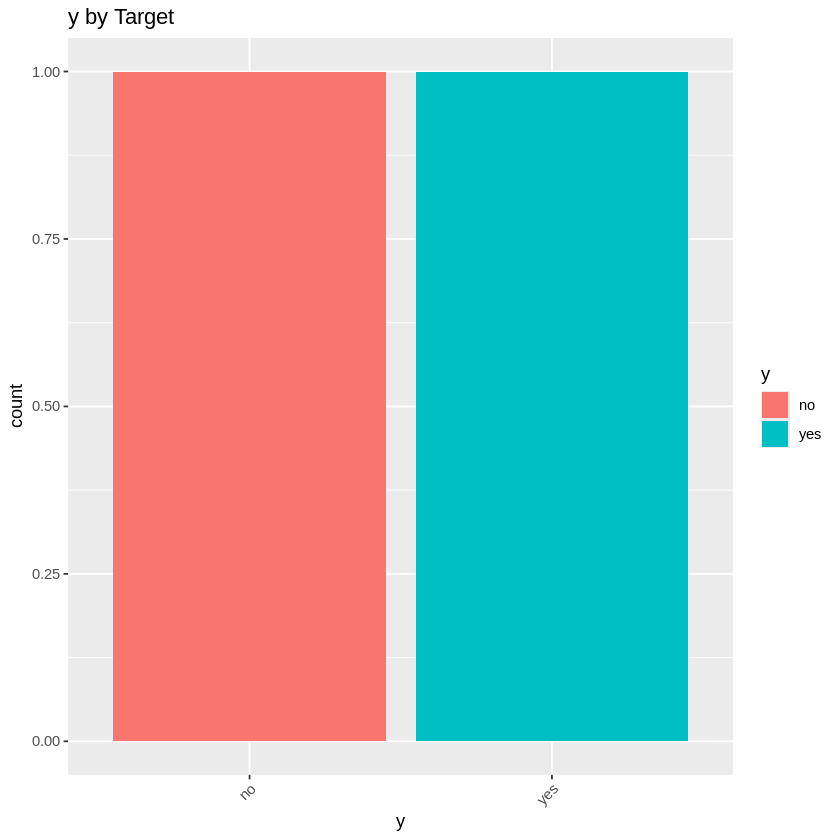

In [ ]:
# Categorical Variables vs Target

for (var in fac_var) {
  print(
    ggplot(marketing_data, aes_string(x = var, fill = "y")) +
      geom_bar(position = "fill") +
      ggtitle(paste(var, "by Target")) +
      theme(axis.text.x = element_text(angle = 45, hjust = 1))
  )
}

### Chi-Square Test

In [ ]:
library(MASS)

# Initialize empty list
chi_results <- data.frame(Feature = character(), P_Value = numeric())

for (var in fac_var) {
  chi_test <- chisq.test(table(marketing_data[[var]], marketing_data$y))
  chi_results <- rbind(chi_results, data.frame(Feature = var, P_Value = chi_test$p.value))
}

# Sort by lowest p-value (most important features)
chi_results <- chi_results[order(chi_results$P_Value), ]
print(chi_results)

Warning message in chisq.test(table(marketing_data[[var]], marketing_data$y)):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(table(marketing_data[[var]], marketing_data$y)):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(table(marketing_data[[var]], marketing_data$y)):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(table(marketing_data[[var]], marketing_data$y)):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(table(marketing_data[[var]], marketing_data$y)):
“Chi-squared approximation may be incorrect”


       Feature      P_Value
11           y 0.000000e+00
10    poutcome 7.227366e-99
8        month 3.631469e-59
7      contact 1.686986e-18
1          job 9.417554e-11
4      default 5.652986e-06
3            k 2.393703e-03
2      marital 1.592923e-02
6         loan 5.755973e-01
5      housing 7.392794e-01
9  day_of_week 9.715335e-01


In [ ]:
#categorical variables to keep
head(chi_results)

,Feature,P_Value
,<chr>,<dbl>
11,y,0.000000e+00
10,poutcome,7.227366e-99
8,month,3.631469e-59
7,contact,1.686986e-18
1,job,9.417554e-11
4,default,5.652986e-06


### Dealing with outliers

First step is to deal with outliers.

In [ ]:
# pdays has alot of outliers because if the customer was not contacted previously it is encoded as 999, how many instances is this
sum(marketing_data$pdays == 999)

[1] 3940

In [ ]:
(3940/4500)*100

[1] 87.55556

87.55% of the data in this column is coded as 999. this shows a low variance and the variable is already correlated to previous, therefor it is worth getting rid of the column.

In [ ]:
# Check variance
#install.packages("caret")
#library(caret)
#nearZeroVar(marketing_data, saveMetrics = TRUE)

In [ ]:
# remove the pdays column from dataframe
marketing_data <- marketing_data |>
  dplyr::select(-pdays)

head(marketing_data)

age,job,marital,k,default,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
39,services,single,high.school,no,no,no,telephone,may,fri,346,4,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
32,services,single,university.degree,no,no,no,cellular,sep,thu,128,3,2,failure,-1.1,94.199,-37.5,0.884,4963.6,no


Now that is removed, the columns with more outliers can be dealt with. Columns with outliers are:
* age
* campaign
* duration
* previous

All of these features exhibit right skewed distribution.

In [ ]:
# conduct log transformations of these variables.

#age
marketing_data$age <- log(marketing_data$age + 1)

#campaign
marketing_data$campaign <- log(marketing_data$campaign + 1)

#duration
marketing_data$duration <- log(marketing_data$duration + 1)

#previous
marketing_data$previous <- log(marketing_data$previous + 1)

Plot histograms for each now:

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


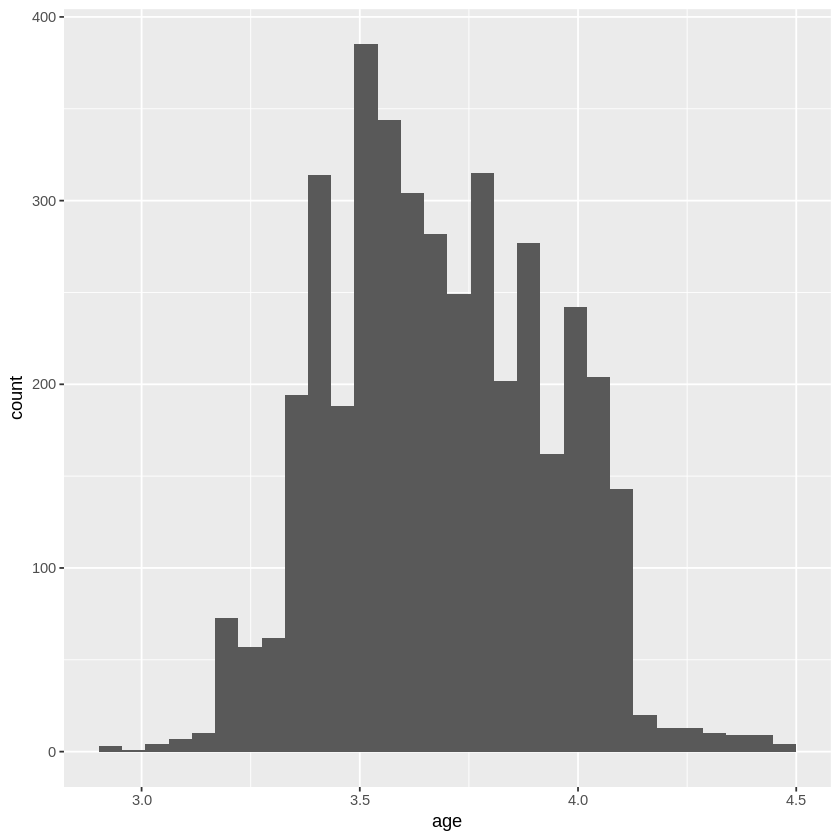

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


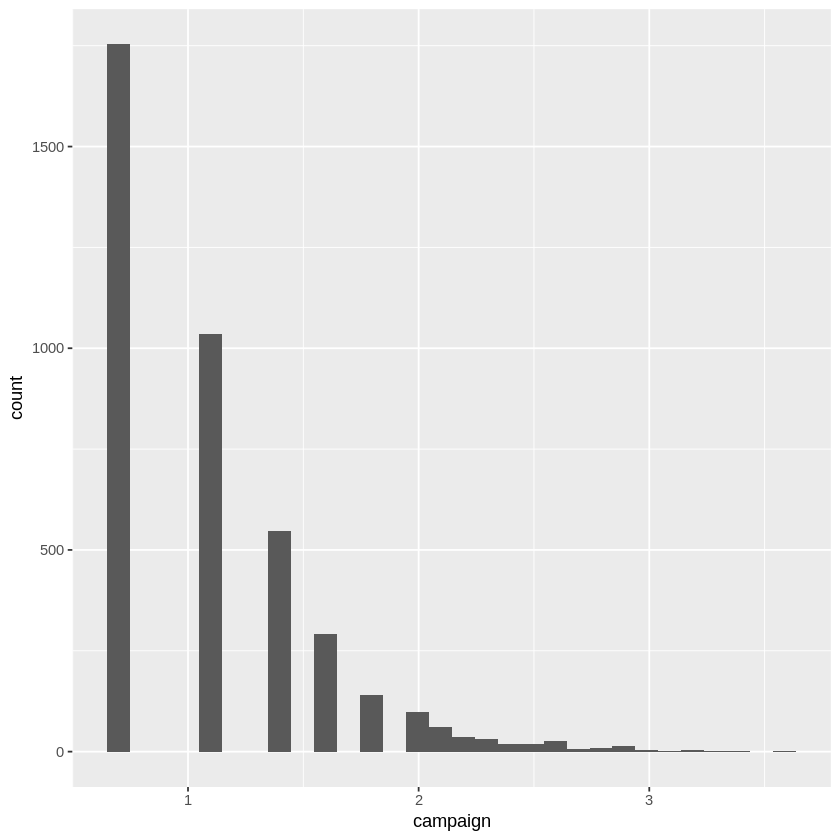

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


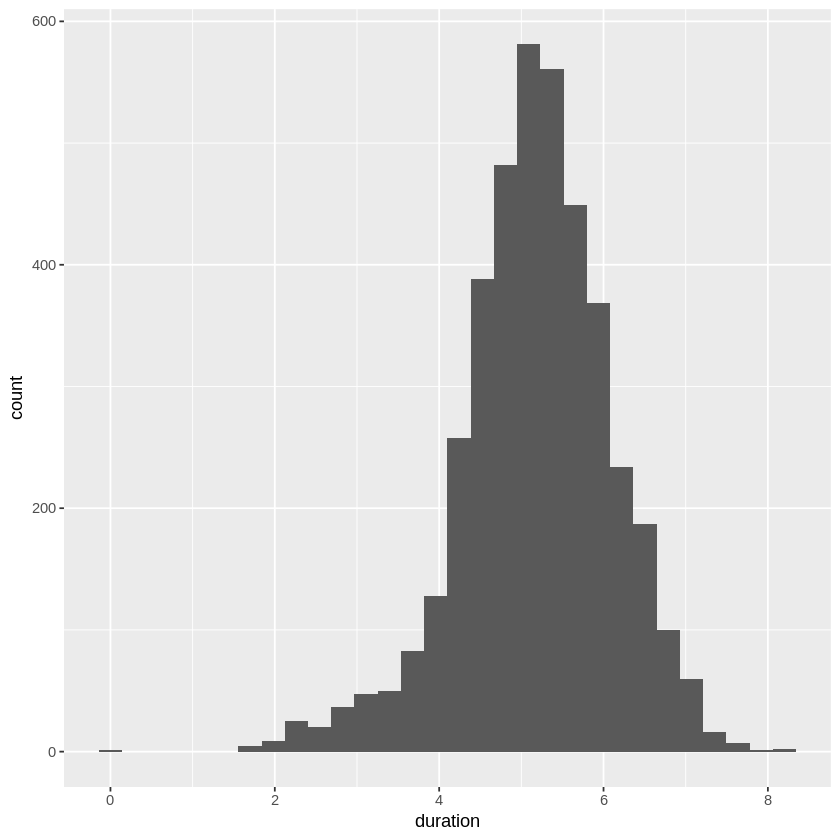

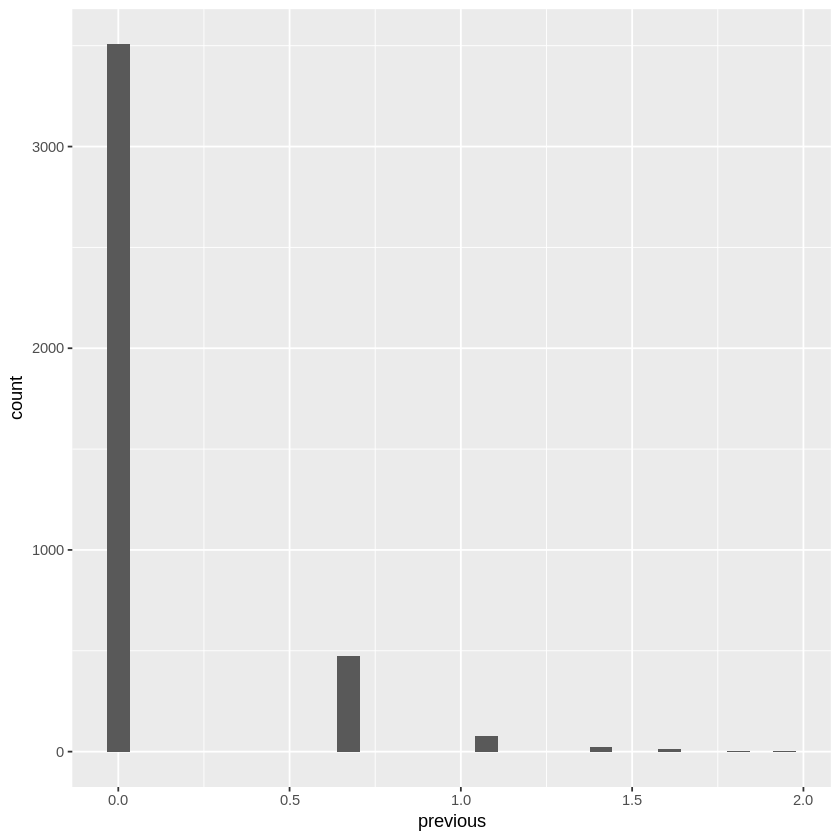

In [ ]:
# age histogram
ggplot(marketing_data, aes(age)) +
  geom_histogram()

# campaign histogram
ggplot(marketing_data, aes(campaign)) +
  geom_histogram()

# duration histogram
ggplot(marketing_data, aes(duration)) +
  geom_histogram()

# previous histogram
ggplot(marketing_data, aes(previous)) +
  geom_histogram()

some of the distributions have become more normal however **previous** and **campaign** are still skewed.

### Encoding Categorical variables.

will use one-hot encoding

In [ ]:
install.packages("mltools")
install.packages("data.table")

library(mltools)
library(data.table)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
marketing_data_encoded <- one_hot(as.data.table(marketing_data |>
  dplyr::select(-y)))

#marketing_data_encoded$y <- marketing_data$y
head(marketing_data_encoded)

age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,⋯,campaign,previous,poutcome_failure,poutcome_nonexistent,poutcome_success,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3.433987,0,1,0,0,0,0,0,0,0,⋯,1.0986123,0.000000,0,1,0,-1.8,92.893,-46.2,1.313,5099.1
3.688879,0,0,0,0,0,0,0,1,0,⋯,1.6094379,0.000000,0,1,0,1.1,93.994,-36.4,4.855,5191.0
3.258097,0,0,0,0,0,0,0,1,0,⋯,0.6931472,0.000000,0,1,0,1.4,94.465,-41.8,4.962,5228.1
3.663562,0,0,0,0,0,0,0,1,0,⋯,1.3862944,0.000000,0,1,0,1.4,94.465,-41.8,4.959,5228.1
3.871201,1,0,0,0,0,0,0,0,0,⋯,0.6931472,0.000000,0,1,0,-0.1,93.200,-42.0,4.191,5195.8
3.496508,0,0,0,0,0,0,0,1,0,⋯,1.3862944,1.098612,1,0,0,-1.1,94.199,-37.5,0.884,4963.6


### Scale the Numerical variables

In [ ]:
# use standardization (z-score) scaling

marketing_data_scaled <- scale(marketing_data_encoded)
head(marketing_data_scaled)

age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,⋯,campaign,previous,poutcome_failure,poutcome_nonexistent,poutcome_success,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
-1.02837085,-0.5697702,1.9085002,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,-0.3251024,-0.1419484,⋯,-0.04037517,-0.3914484,-0.3519564,0.4115611,-0.1893884,-1.2059819,-1.1855576,-1.2412493,-1.3314933,-0.9145881
0.01127615,-0.5697702,-0.5238439,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,3.0752035,-0.1419484,⋯,1.01317527,-0.3914484,-0.3519564,0.4115611,-0.1893884,0.6492068,0.7141002,0.8922533,0.7115263,0.3329579
-1.74578852,-0.5697702,-0.5238439,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,3.0752035,-0.1419484,⋯,-0.87662520,-0.3914484,-0.3519564,0.4115611,-0.1893884,0.8411229,1.5267604,-0.2833502,0.7732437,0.8365919
-0.09198938,-0.5697702,-0.5238439,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,3.0752035,-0.1419484,⋯,0.55295367,-0.3914484,-0.3519564,0.4115611,-0.1893884,0.8411229,1.5267604,-0.2833502,0.7715133,0.8365919
0.75492395,1.7546655,-0.5238439,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,-0.3251024,-0.1419484,⋯,-0.87662520,-0.3914484,-0.3519564,0.4115611,-0.1893884,-0.1184575,-0.6558619,-0.3268910,0.3285322,0.3981181
-0.77336466,-0.5697702,-0.5238439,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,3.0752035,-0.1419484,⋯,0.55295367,3.2956055,2.8405682,-2.4291804,-0.1893884,-0.7581777,1.0678058,0.6527785,-1.5789398,-2.7540057


In [ ]:
# Check the mean of every variable is 0
summary(marketing_data_scaled)

      age             job_admin.      job_blue-collar   job_entrepreneur 
 Min.   :-3.02513   Min.   :-0.5698   Min.   :-0.5238   Min.   :-0.1921  
 1st Qu.:-0.77336   1st Qu.:-0.5698   1st Qu.:-0.5238   1st Qu.:-0.1921  
 Median :-0.09199   Median :-0.5698   Median :-0.5238   Median :-0.1921  
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.75492   3rd Qu.:-0.5698   3rd Qu.:-0.5238   3rd Qu.:-0.1921  
 Max.   : 3.27330   Max.   : 1.7547   Max.   : 1.9085   Max.   : 5.2034  
 job_housemaid     job_management     job_retired      job_self-employed
 Min.   :-0.1645   Min.   :-0.2924   Min.   :-0.2047   Min.   :-0.2008  
 1st Qu.:-0.1645   1st Qu.:-0.2924   1st Qu.:-0.2047   1st Qu.:-0.2008  
 Median :-0.1645   Median :-0.2924   Median :-0.2047   Median :-0.2008  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.:-0.1645   3rd Qu.:-0.2924   3rd Qu.:-0.2047   3rd Qu.:-0.2008  
 Max.   : 6.0790   Max.   : 3.4192   Max.   

In [ ]:
# convert back to dataframe
marketing_data_scaled <- as.data.frame(marketing_data_scaled)

# add y column
marketing_data_scaled$y <- marketing_data$y

# view dataframe
head(marketing_data_scaled)

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,⋯,previous,poutcome_failure,poutcome_nonexistent,poutcome_success,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,-1.02837085,-0.5697702,1.9085002,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,-0.3251024,-0.1419484,⋯,-0.3914484,-0.3519564,0.4115611,-0.1893884,-1.2059819,-1.1855576,-1.2412493,-1.3314933,-0.9145881,no
2,0.01127615,-0.5697702,-0.5238439,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,3.0752035,-0.1419484,⋯,-0.3914484,-0.3519564,0.4115611,-0.1893884,0.6492068,0.7141002,0.8922533,0.7115263,0.3329579,no
3,-1.74578852,-0.5697702,-0.5238439,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,3.0752035,-0.1419484,⋯,-0.3914484,-0.3519564,0.4115611,-0.1893884,0.8411229,1.5267604,-0.2833502,0.7732437,0.8365919,no
4,-0.09198938,-0.5697702,-0.5238439,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,3.0752035,-0.1419484,⋯,-0.3914484,-0.3519564,0.4115611,-0.1893884,0.8411229,1.5267604,-0.2833502,0.7715133,0.8365919,no
5,0.75492395,1.7546655,-0.5238439,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,-0.3251024,-0.1419484,⋯,-0.3914484,-0.3519564,0.4115611,-0.1893884,-0.1184575,-0.6558619,-0.3268910,0.3285322,0.3981181,no
6,-0.77336466,-0.5697702,-0.5238439,-0.1921344,-0.1644613,-0.2923983,-0.2047466,-0.2008364,3.0752035,-0.1419484,⋯,3.2956055,2.8405682,-2.4291804,-0.1893884,-0.7581777,1.0678058,0.6527785,-1.5789398,-2.7540057,no


In [ ]:
# check number of observations is preserved
dim(marketing_data_scaled)

[1] 4100   63

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



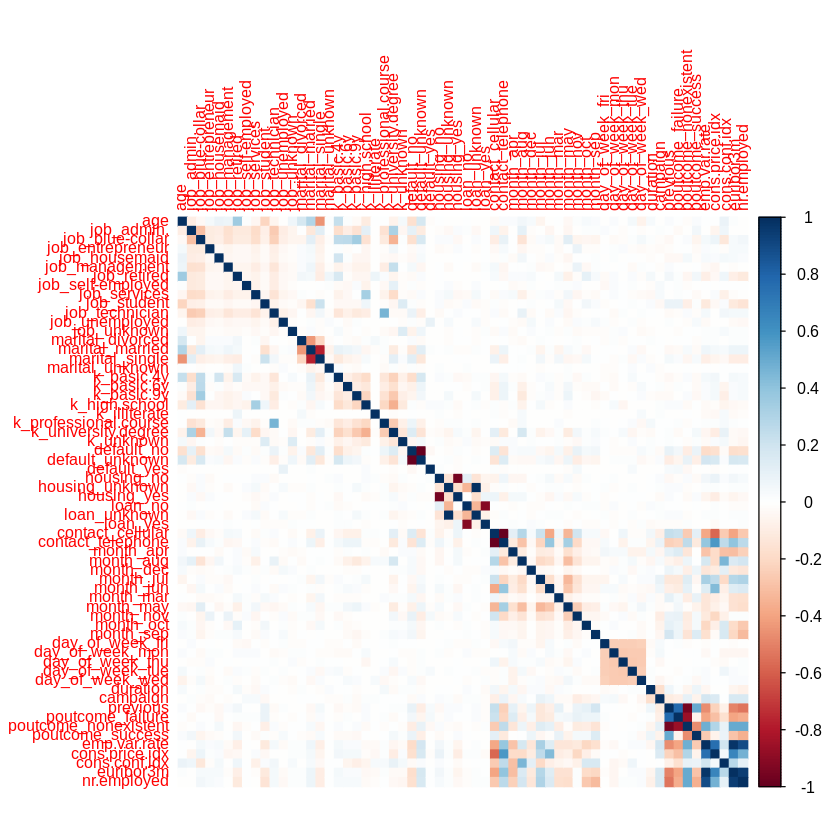

In [ ]:
# Correlation matrix
cor_matrix_scaled <- cor(marketing_data_scaled |> dplyr::select(-y), use = "complete.obs")

# Heatmap
install.packages("corrplot")
library(corrplot)
corrplot(cor_matrix_scaled, method = "color", tl.cex = 0.8)

### Split the data

In [ ]:
# set seed
set.seed(42)
#split the data
sample <- sample(c(TRUE, FALSE), nrow(marketing_data_scaled), replace=TRUE, prob=c(0.8, 0.2))

train_data <- marketing_data_scaled[sample,]

test_data <- marketing_data_scaled[!sample,]

In [ ]:
# Split the data into labels and features

#train set
x_train <- train_data |>
  dplyr::select(-y)

y_train <- train_data$y

#test set
x_test <- test_data |>
  dplyr::select(-y)

y_test <- test_data$y

## Train a Logistic regression model

In [ ]:
# set seed
set.seed(42)

# fit logistic regression model
model <- glm(y ~ ., data = train_data, family = "binomial")

model

# summary of model
summary(model)


Call:  glm(formula = y ~ ., family = "binomial", data = train_data)

Coefficients:
          (Intercept)                    age             job_admin.  
           -4.0901128              0.0527173              0.2608773  
    `job_blue-collar`       job_entrepreneur          job_housemaid  
            0.1376061             -0.0245127              0.0754302  
       job_management            job_retired    `job_self-employed`  
            0.1263585              0.0566666              0.0316947  
         job_services            job_student         job_technician  
            0.2345034              0.0862139              0.3372632  
       job_unemployed            job_unknown       marital_divorced  
            0.1332583                     NA             -0.2162765  
      marital_married         marital_single        marital_unknown  
           -0.2084178             -0.2022454                     NA  
           k_basic.4y             k_basic.6y             k_basic.9y  
      


Call:
glm(formula = y ~ ., family = "binomial", data = train_data)

Coefficients: (11 not defined because of singularities)
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)           -4.090e+00  2.490e-01 -16.428  < 2e-16 ***
age                    5.272e-02  9.581e-02   0.550   0.5822    
job_admin.             2.609e-01  3.504e-01   0.744   0.4566    
`job_blue-collar`      1.376e-01  3.376e-01   0.408   0.6835    
job_entrepreneur      -2.451e-02  1.753e-01  -0.140   0.8888    
job_housemaid          7.543e-02  1.529e-01   0.493   0.6218    
job_management         1.264e-01  2.270e-01   0.557   0.5777    
job_retired            5.667e-02  1.688e-01   0.336   0.7371    
`job_self-employed`    3.169e-02  1.724e-01   0.184   0.8541    
job_services           2.345e-01  2.466e-01   0.951   0.3416    
job_student            8.621e-02  1.250e-01   0.690   0.4903    
job_technician         3.373e-01  3.066e-01   1.100   0.2713    
job_unemployed         1.333e-

In [ ]:
# make predictions
pred <- predict(model, x_test, type="response")

In [ ]:
# changing probabilities
preds <- ifelse(pred > 0.5, "yes", "no")

# confusion matrix
table(test_data$y, preds)

     preds
       no yes
  no  736  23
  yes  48  42

In [ ]:
# use caret for metrics
install.packages("caret")
library(caret)

conf_matrix_glm1 <- confusionMatrix(as.factor(preds), y_test, positive = "yes")
conf_matrix_glm1

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Confusion Matrix and Statistics

          Reference
Prediction  no yes
       no  736  48
       yes  23  42
                                          
               Accuracy : 0.9164          
                 95% CI : (0.8957, 0.9341)
    No Information Rate : 0.894           
    P-Value [Acc > NIR] : 0.017187        
                                          
                  Kappa : 0.4972          
                                          
 Mcnemar's Test P-Value : 0.004396        
                                          
            Sensitivity : 0.46667         
            Specificity : 0.96970         
         Pos Pred Value : 0.64615         
         Neg Pred Value : 0.93878         
             Prevalence : 0.10601         
         Detection Rate : 0.04947         
   Detection Prevalence : 0.07656         
      Balanced Accuracy : 0.71818         
                                          
       'Positive' Class : yes             
                              

In [ ]:
# Confusion Matrix
conf_matrix_glm1 <- confusionMatrix(as.factor(preds), y_test, positive = "yes")
conf_matrix_glm1

# Extract Precision, Recall, and F1-score
precision_glm1 <- conf_matrix_glm1$byClass["Precision"]
recall_glm1 <- conf_matrix_glm1$byClass["Recall"]
f1_score_glm1 <- conf_matrix_glm1$byClass["F1"]

# Print results
precision_glm1
recall_glm1
f1_score_glm1

Precision 
0.6461538

Recall 
0.4666667

F1 
0.5419355

In [ ]:
# Accuracy
1 - mean(preds != y_test)

[1] 0.9163722

ROC Curve and AUC

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] 0.9217099

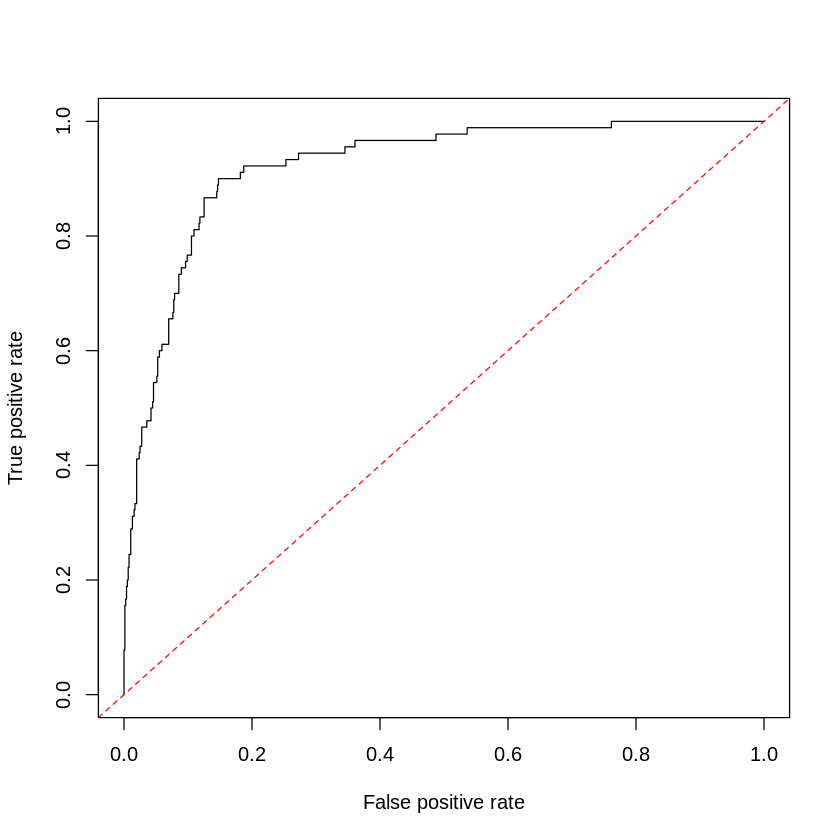

In [ ]:
install.packages("ROCR")
library(ROCR)

pred <- prediction(pred, test_data$y)
perf <- performance(pred, measure = "tpr", x.measure = "fpr")
plot(perf)

# Add a diagonal reference line
abline(a = 0, b = 1, col = "red", lty = 2)

auc <- performance(pred, measure = "auc")
auc <- auc@y.values[[1]]
auc

In [ ]:
auc

[1] 0.9217099

## KNN model

In [ ]:
install.packages("caret")
library(caret)

set.seed(42)

knn_model1 <- knn3(x = x_train,
                   y = y_train,
                   k = 65)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Predict probabilities for the test set
knn_probs1 <- predict(knn_model1, x_test)[, 2]

# changing probabilities
conf_pred_knn1 <- ifelse(knn_probs1 > 0.5, "yes", "no")

# confusion matrix
table(y_test, conf_pred_knn1)

      conf_pred_knn1
y_test  no yes
   no  758   1
   yes  82   8

In [ ]:
# Confusion Matrix
conf_matrix_knn1 <- confusionMatrix(as.factor(conf_pred_knn1), y_test, positive = "yes")
conf_matrix_knn1

# Extract Precision, Recall, and F1-score
precision_knn1 <- conf_matrix_knn1$byClass["Precision"]
recall_knn1 <- conf_matrix_knn1$byClass["Recall"]
f1_score_knn1 <- conf_matrix_knn1$byClass["F1"]

# Print results
precision_knn1
recall_knn1
f1_score_knn1

Confusion Matrix and Statistics

          Reference
Prediction  no yes
       no  758  82
       yes   1   8
                                          
               Accuracy : 0.9022          
                 95% CI : (0.8803, 0.9214)
    No Information Rate : 0.894           
    P-Value [Acc > NIR] : 0.2365          
                                          
                  Kappa : 0.1451          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.088889        
            Specificity : 0.998682        
         Pos Pred Value : 0.888889        
         Neg Pred Value : 0.902381        
             Prevalence : 0.106007        
         Detection Rate : 0.009423        
   Detection Prevalence : 0.010601        
      Balanced Accuracy : 0.543786        
                                          
       'Positive' Class : yes             
                              

Precision 
0.8888889

Recall 
0.08888889

F1 
0.1616162

In [ ]:
#Accuracy
1 - mean(conf_pred_knn1 != y_test)

[1] 0.9022379

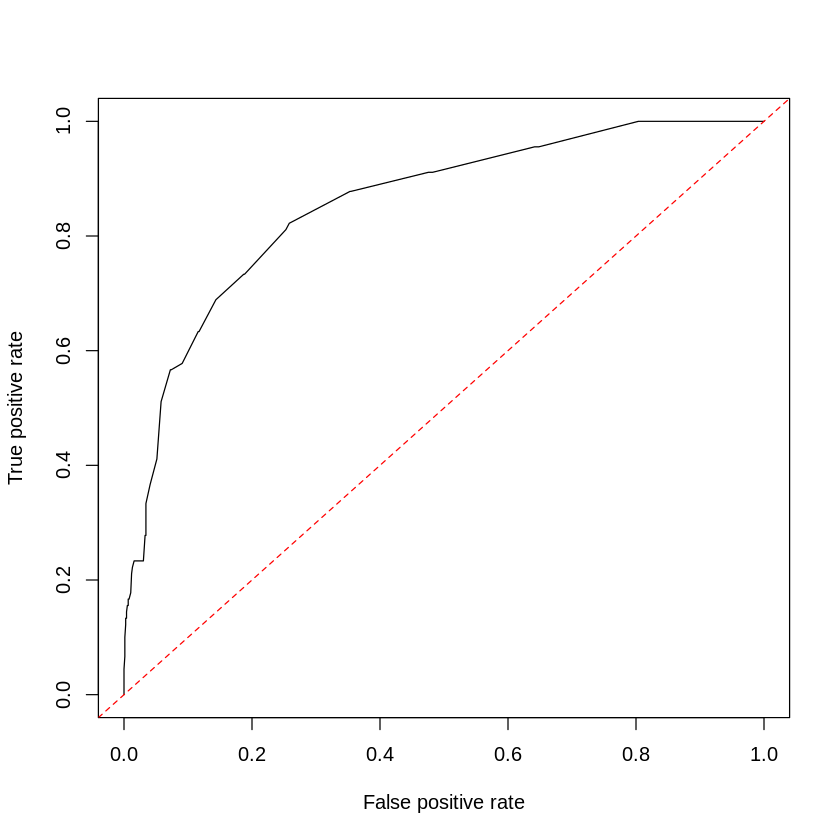

In [ ]:
#Create prediction object
knn_pred1 <- prediction(knn_probs1, y_test)

#Performance object
knn_perf <- performance(knn_pred1, "tpr", "fpr")

# Plot
plot(knn_perf)
# Add a diagonal reference line
abline(a = 0, b = 1, col = "red", lty = 2)

In [ ]:
# AUC
knn_auc_perf <- performance(knn_pred1, measure = "auc")
knn_auc <- knn_auc_perf@y.values[[1]]
knn_auc

[1] 0.8539087

## Try Random Forest

In [ ]:
install.packages("randomForest")
library(randomForest)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:

# Set seed
set.seed(42)

# Train model
model_rf <- randomForest(x = x_train,
                         y = y_train,
                         ntree = 500,
                         importance = TRUE)

model_rf


Call:
 randomForest(x = x_train, y = y_train, ntree = 500, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 7

        OOB estimate of  error rate: 9.1%
Confusion matrix:
      no yes class.error
no  2819  71  0.02456747
yes  225 136  0.62326870

In [ ]:
# make predictions for yes/positive class
pred_rf <- predict(model_rf, x_test, type="prob")[, 2]

# changing probabilities
conf_pred_rf <- ifelse(pred_rf > 0.5, "yes", "no")

# confusion matrix
table(y_test, conf_pred_rf)

      conf_pred_rf
y_test  no yes
   no  739  20
   yes  57  33

In [ ]:
conf_matrix_rf <- confusionMatrix(as.factor(conf_pred_rf), y_test, positive = "yes")
conf_matrix_rf

# Extract Precision, Recall, and F1-score
precision_rf <- conf_matrix_rf$byClass["Precision"]
recall_rf <- conf_matrix_rf$byClass["Recall"]
f1_score_rf <- conf_matrix_rf$byClass["F1"]

# Print results
precision_rf
recall_rf
f1_score_rf

Confusion Matrix and Statistics

          Reference
Prediction  no yes
       no  739  57
       yes  20  33
                                         
               Accuracy : 0.9093         
                 95% CI : (0.888, 0.9278)
    No Information Rate : 0.894          
    P-Value [Acc > NIR] : 0.07946        
                                         
                  Kappa : 0.4156         
                                         
 Mcnemar's Test P-Value : 4.086e-05      
                                         
            Sensitivity : 0.36667        
            Specificity : 0.97365        
         Pos Pred Value : 0.62264        
         Neg Pred Value : 0.92839        
             Prevalence : 0.10601        
         Detection Rate : 0.03887        
   Detection Prevalence : 0.06243        
      Balanced Accuracy : 0.67016        
                                         
       'Positive' Class : yes            
                                         

Precision 
0.6226415

Recall 
0.3666667

F1 
0.4615385

In [ ]:
#Accuracy
1 - mean(conf_pred_rf != y_test)

[1] 0.9093051

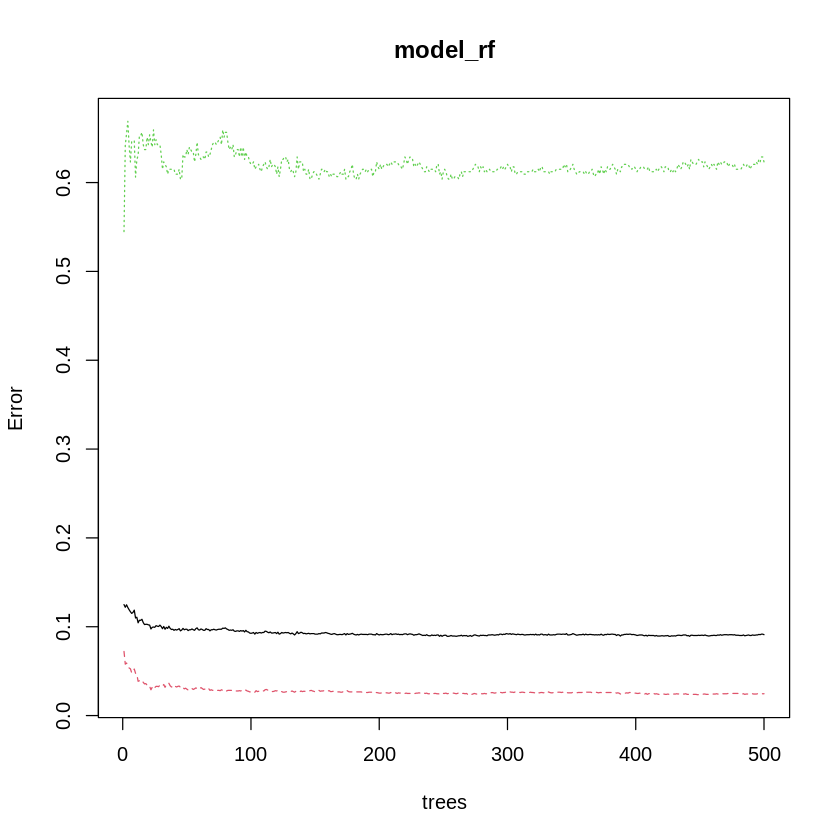

In [ ]:
plot(model_rf)

In [ ]:
# Importance plot
importance(model_rf)

,no,yes,MeanDecreaseAccuracy,MeanDecreaseGini
age,8.58372485,-0.886994169,7.60695524,3.828274e+01
job_admin.,0.01196881,0.847080562,0.41957487,7.351099e+00
job_blue-collar,-0.52984653,1.854587761,0.49052687,4.959010e+00
job_entrepreneur,-2.03229376,2.805395412,-0.51455835,1.406960e+00
job_housemaid,-1.79206376,1.657651188,-0.68752555,1.046120e+00
job_management,-1.45741432,0.574801829,-0.99091269,3.684841e+00
job_retired,5.50034030,-3.591736449,3.47180209,3.745805e+00
job_self-employed,0.28213883,1.513702971,1.01726495,2.119851e+00
job_services,0.42498325,-0.779636993,0.04373031,4.260082e+00
job_student,2.36340756,3.725900493,3.89383644,2.305195e+00


The nclass + 1st column is the mean descrease in accuracy over all classes. The last column is the mean decrease in Gini index

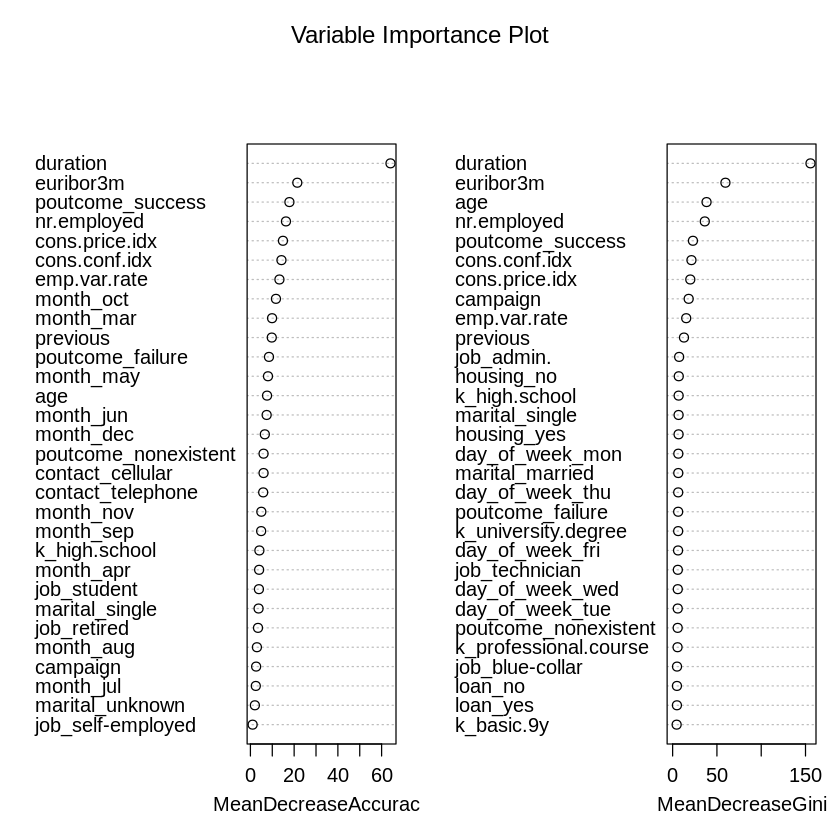

In [ ]:
# Variable importance plot
varImpPlot(model_rf,
           main="Variable Importance Plot")

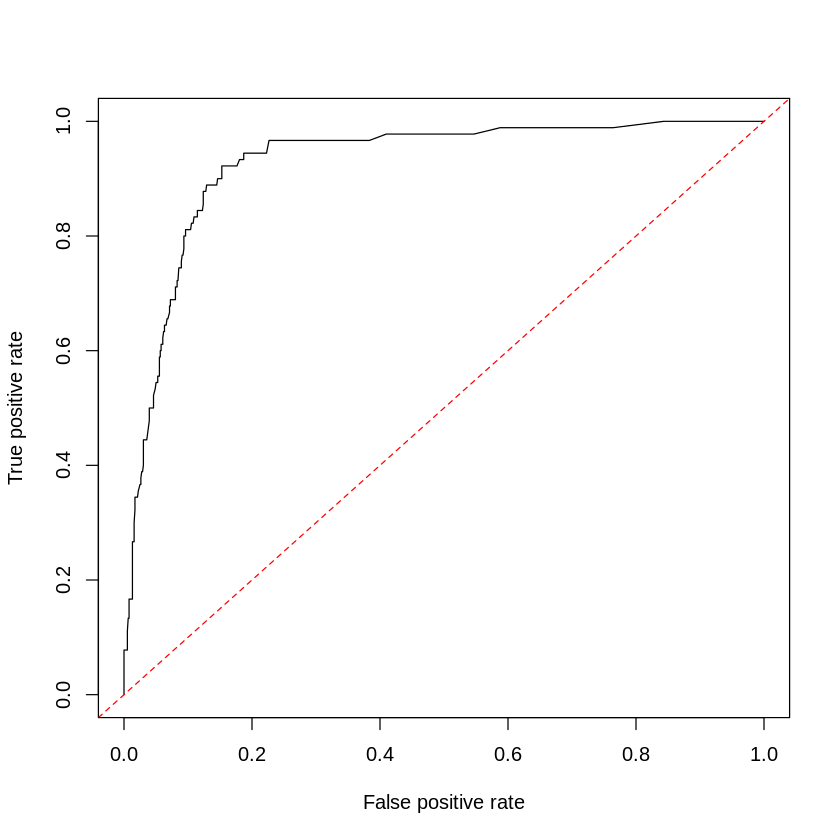

In [ ]:
#Create prediction object
rf_pred <- prediction(as.numeric(pred_rf), as.numeric(y_test))

#Performance object
rf_perf <- performance(rf_pred, "tpr", "fpr")

# Plot
plot(rf_perf)
# Add a diagonal reference line
abline(a = 0, b = 1, col = "red", lty = 2)

In [ ]:
# AUC
rf_auc_perf <- performance(rf_pred, measure = "auc")
rf_auc <- rf_auc_perf@y.values[[1]]
rf_auc

[1] 0.9272874

## Let's do some feature selection and retry performance of models on less features

In [ ]:
# check important categorical features
print(chi_results)

       Feature      P_Value
11           y 0.000000e+00
10    poutcome 7.227366e-99
8        month 3.631469e-59
7      contact 1.686986e-18
1          job 9.417554e-11
4      default 5.652986e-06
3            k 2.393703e-03
2      marital 1.592923e-02
6         loan 5.755973e-01
5      housing 7.392794e-01
9  day_of_week 9.715335e-01


This shows the top 5 categorical features are:
* poutcome
* month
* contact
* Job
* default

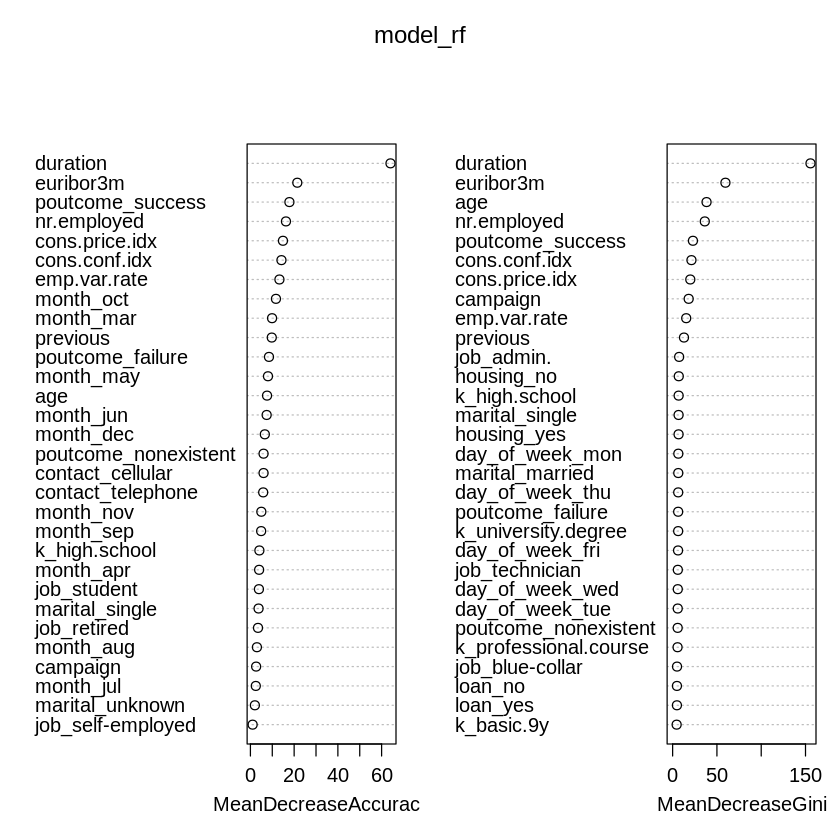

In [ ]:
# Check feature Importance based on Random Forest model
# Variable importance plot
varImpPlot(model_rf)

Important Features:
* duration
* euribor3m
* age
* nr.employed
* poutcome

and more.

It looks like these variables are correlated:

pdays and previous

emp.var.rate with nr.employed, cons.price.idx and euribor3m

euribor3m with emp.var.rate and nr.employed

keep these variables based on the above:
* duration
* euribor3m
* age
* nr.employed
* poutcome
* campaign


### Prepare the new data again

In [ ]:
#import the data fresh
marketing_data <- read_csv("/content/MMA marketing_data_sample.csv")

Rows: 4100 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): job, marital, k, default, housing, loan, contact, month, day_of_we...
dbl (10): age, duration, campaign, pdays, previous, emp.var.rate, cons.price...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
# create new dataframe with the selected features
selected_data <- marketing_data |>
  mutate_if(is.character, as.factor) |>
  dplyr::select(duration, euribor3m, age, nr.employed, poutcome, campaign, y)

head(selected_data)

duration,euribor3m,age,nr.employed,poutcome,campaign,y
<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<fct>
487,1.313,30,5099.1,nonexistent,2,no
346,4.855,39,5191.0,nonexistent,4,no
227,4.962,25,5228.1,nonexistent,1,no
17,4.959,38,5228.1,nonexistent,3,no
58,4.191,47,5195.8,nonexistent,1,no
128,0.884,32,4963.6,failure,3,no


In [ ]:
# conduct log transformations of these variables to reduce the effect of outliers

#age
selected_data$age <- log(selected_data$age + 1)

#campaign
selected_data$campaign <- log(selected_data$campaign + 1)

#duration
selected_data$duration <- log(selected_data$duration + 1)

In [ ]:
# one-hot encode variables

install.packages("mltools")
install.packages("data.table")

library(mltools)
library(data.table)

selected_data_encoded <- one_hot(as.data.table(selected_data |>
  dplyr::select(-y)))


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
#use standardization (z-score) scaling

selected_data_scaled <- scale(selected_data_encoded)
head(selected_data_scaled)

duration,euribor3m,age,nr.employed,poutcome_failure,poutcome_nonexistent,poutcome_success,campaign
1.1121321,-1.3314933,-1.02837085,-0.9145881,-0.3519564,0.4115611,-0.1893884,-0.04037517
0.7390036,0.7115263,0.01127615,0.3329579,-0.3519564,0.4115611,-0.1893884,1.01317527
0.2794421,0.7732437,-1.74578852,0.8365919,-0.3519564,0.4115611,-0.1893884,-0.87662520
-2.4988263,0.7715133,-0.09198938,0.8365919,-0.3519564,0.4115611,-0.1893884,0.55295367
-1.1997720,0.3285322,0.75492395,0.3981181,-0.3519564,0.4115611,-0.1893884,-0.87662520
-0.3437688,-1.5789398,-0.77336466,-2.7540057,2.8405682,-2.4291804,-0.1893884,0.55295367


In [ ]:
# convert back to dataframe
selected_data_scaled <- as.data.frame(selected_data_scaled)

# add y column
selected_data_scaled$y <- selected_data$y

# view dataframe
head(selected_data_scaled)

,duration,euribor3m,age,nr.employed,poutcome_failure,poutcome_nonexistent,poutcome_success,campaign,y
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,1.1121321,-1.3314933,-1.02837085,-0.9145881,-0.3519564,0.4115611,-0.1893884,-0.04037517,no
2,0.7390036,0.7115263,0.01127615,0.3329579,-0.3519564,0.4115611,-0.1893884,1.01317527,no
3,0.2794421,0.7732437,-1.74578852,0.8365919,-0.3519564,0.4115611,-0.1893884,-0.87662520,no
4,-2.4988263,0.7715133,-0.09198938,0.8365919,-0.3519564,0.4115611,-0.1893884,0.55295367,no
5,-1.1997720,0.3285322,0.75492395,0.3981181,-0.3519564,0.4115611,-0.1893884,-0.87662520,no
6,-0.3437688,-1.5789398,-0.77336466,-2.7540057,2.8405682,-2.4291804,-0.1893884,0.55295367,no


In [ ]:
# set seed
set.seed(42)

#split the data
sample <- sample(c(TRUE, FALSE), nrow(selected_data_scaled), replace=TRUE, prob=c(0.8, 0.2))

train_data <- selected_data_scaled[sample,]

test_data <- selected_data_scaled[!sample,]

In [ ]:
# Split the data into labels and features

#train set
x_train <- train_data |>
  dplyr::select(-y)

y_train <- train_data$y

#test set
x_test <- test_data |>
  dplyr::select(-y)

y_test <- test_data$y

###Train logistic regression model

In [ ]:
# set seed
set.seed(42)

# fit logistic regression model
glm_model <- glm(y ~ ., data = train_data, family = "binomial")

glm_model

# summary of model
summary(glm_model)


Call:  glm(formula = y ~ ., family = "binomial", data = train_data)

Coefficients:
         (Intercept)              duration             euribor3m  
            -3.68858               2.07504              -0.06146  
                 age           nr.employed      poutcome_failure  
            -0.00421              -0.97625              -0.74161  
poutcome_nonexistent      poutcome_success              campaign  
            -0.67053                    NA              -0.02629  

Degrees of Freedom: 3250 Total (i.e. Null);  3243 Residual
Null Deviance:	    2267 
Residual Deviance: 1319 	AIC: 1335


Call:
glm(formula = y ~ ., family = "binomial", data = train_data)

Coefficients: (1 not defined because of singularities)
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -3.68858    0.14006 -26.335  < 2e-16 ***
duration              2.07504    0.11347  18.287  < 2e-16 ***
euribor3m            -0.06146    0.17522  -0.351    0.726    
age                  -0.00421    0.06620  -0.064    0.949    
nr.employed          -0.97625    0.16560  -5.895 3.74e-09 ***
poutcome_failure     -0.74161    0.09699  -7.646 2.07e-14 ***
poutcome_nonexistent -0.67053    0.09808  -6.837 8.10e-12 ***
poutcome_success           NA         NA      NA       NA    
campaign             -0.02629    0.08856  -0.297    0.767    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 2267.2  on 3250  degrees of freedom
Residual deviance: 1318.9  on 3243  degrees of freedom
AIC: 1334.9

Number 

In [ ]:
# make predictions
glm_pred <- predict(glm_model, x_test, type="response")

# changing probabilities
glm_preds <- ifelse(glm_pred > 0.5, "yes", "no")

# confusion matrix
table(y_test, preds)

# Accuracy
1 - mean(glm_preds != y_test)

      preds
y_test  no yes
   no  736  23
   yes  48  42

[1] 0.9128386

In [ ]:
# Confusion Matrix
conf_matrix_glm2 <- confusionMatrix(as.factor(glm_preds), y_test, positive = "yes")
conf_matrix_glm2

# Extract Precision, Recall, and F1-score
precision_glm2 <- conf_matrix_glm2$byClass["Precision"]
recall_glm2 <- conf_matrix_glm2$byClass["Recall"]
f1_score_glm2 <- conf_matrix_glm2$byClass["F1"]

# Print results
precision_glm2
recall_glm2
f1_score_glm2

Confusion Matrix and Statistics

          Reference
Prediction  no yes
       no  742  57
       yes  17  33
                                          
               Accuracy : 0.9128          
                 95% CI : (0.8918, 0.9309)
    No Information Rate : 0.894           
    P-Value [Acc > NIR] : 0.0392          
                                          
                  Kappa : 0.4281          
                                          
 Mcnemar's Test P-Value : 5.797e-06       
                                          
            Sensitivity : 0.36667         
            Specificity : 0.97760         
         Pos Pred Value : 0.66000         
         Neg Pred Value : 0.92866         
             Prevalence : 0.10601         
         Detection Rate : 0.03887         
   Detection Prevalence : 0.05889         
      Balanced Accuracy : 0.67213         
                                          
       'Positive' Class : yes             
                              

Precision 
     0.66

Recall 
0.3666667

F1 
0.4714286

ROC curve and AUC

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] 0.9062363

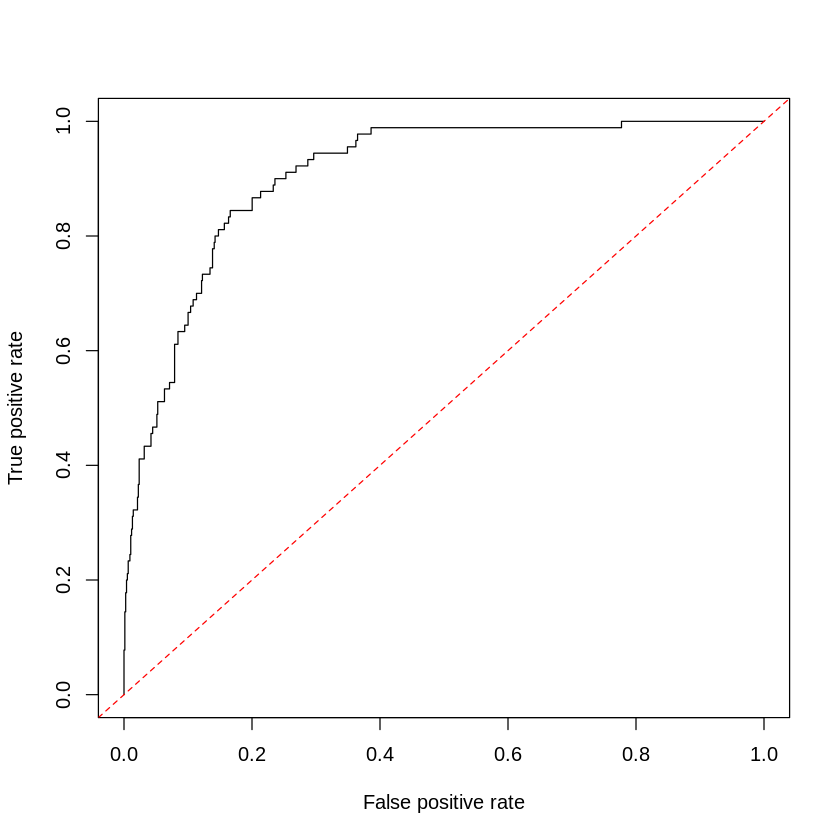

In [ ]:
install.packages("ROCR")
library(ROCR)

glm_pred <- prediction(glm_pred, y_test)
glm_perf <- performance(glm_pred, measure = "tpr", x.measure = "fpr")
plot(glm_perf)

# Add a diagonal reference line
abline(a = 0, b = 1, col = "red", lty = 2)

glm_auc <- performance(glm_pred, measure = "auc")
glm_auc <- glm_auc@y.values[[1]]
glm_auc

### KNN model using caret package instead

In [ ]:
install.packages("caret")
library(caret)

set.seed(42)

knn_model2 <- knn3(x = x_train,
                   y = y_train,
                   k = 65)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Predict probabilities for the test set
knn_probs <- predict(knn_model2, x_test)[, 2]

# changing probabilities
conf_pred_knn <- ifelse(knn_probs > 0.5, "yes", "no")

# confusion matrix
table(y_test, conf_pred_knn)

      conf_pred_knn
y_test  no yes
   no  750   9
   yes  76  14

In [ ]:
# Confusion Matrix
conf_matrix_knn2 <- confusionMatrix(as.factor(conf_pred_knn), y_test, positive = "yes")
conf_matrix_knn2

# Extract Precision, Recall, and F1-score
precision_knn2 <- conf_matrix_knn2$byClass["Precision"]
recall_knn2 <- conf_matrix_knn2$byClass["Recall"]
f1_score_knn2 <- conf_matrix_knn2$byClass["F1"]

# Print results
precision_knn2
recall_knn2
f1_score_knn2

Confusion Matrix and Statistics

          Reference
Prediction  no yes
       no  750  76
       yes   9  14
                                          
               Accuracy : 0.8999          
                 95% CI : (0.8777, 0.9192)
    No Information Rate : 0.894           
    P-Value [Acc > NIR] : 0.3118          
                                          
                  Kappa : 0.2139          
                                          
 Mcnemar's Test P-Value : 8.144e-13       
                                          
            Sensitivity : 0.15556         
            Specificity : 0.98814         
         Pos Pred Value : 0.60870         
         Neg Pred Value : 0.90799         
             Prevalence : 0.10601         
         Detection Rate : 0.01649         
   Detection Prevalence : 0.02709         
      Balanced Accuracy : 0.57185         
                                          
       'Positive' Class : yes             
                              

Precision 
0.6086957

Recall 
0.1555556

F1 
0.2477876

In [ ]:
knn_probs

[1] 0.27692308 0.03076923 0.00000000 0.00000000 0.23076923 0.01538462
  [7] 0.06153846 0.32307692 0.00000000 0.00000000 0.00000000 0.12307692
 [13] 0.10769231 0.00000000 0.00000000 0.18461538 0.01538462 0.01538462
 [19] 0.04615385 0.01538462 0.12307692 0.04615385 0.00000000 0.23076923
 [25] 0.16923077 0.01538462 0.07692308 0.00000000 0.00000000 0.01538462
 [31] 0.00000000 0.35384615 0.00000000 0.06153846 0.00000000 0.21538462
 [37] 0.29230769 0.06153846 0.01538462 0.00000000 0.13846154 0.29230769
 [43] 0.00000000 0.00000000 0.00000000 0.00000000 0.06153846 0.00000000
 [49] 0.03076923 0.00000000 0.00000000 0.27692308 0.07692308 0.00000000
 [55] 0.00000000 0.03076923 0.00000000 0.00000000 0.00000000 0.01538462
 [61] 0.00000000 0.24615385 0.06153846 0.00000000 0.00000000 0.00000000
 [67] 0.00000000 0.35384615 0.00000000 0.00000000 0.00000000 0.07692308
 [73] 0.06153846 0.00000000 0.00000000 0.00000000 0.07692308 0.06153846
 [79] 0.01538462 0.00000000 0.00000000 0.30769231 0.00000000 0.00000000
 [85] 0.06153846 0.01538462 0.03076923 0.00000000 0.00000000 0.00000000
 [91] 0.00000000 0.12307692 0.24615385 0.00000000 0.01538462 0.73846154
 [97] 0.00000000 0.00000000 0.40000000 0.21538462 0.24615385 0.00000000
[103] 0.03076923 0.00000000 0.18461538 0.07692308 0.01538462 0.01538462
[109] 0.00000000 0.00000000 0.04615385 0.33846154 0.04615385 0.00000000
[115] 0.40000000 0.00000000 0.00000000 0.00000000 0.06153846 0.00000000
[121] 0.00000000 0.00000000 0.01538462 0.00000000 0.00000000 0.07692308
[127] 0.00000000 0.00000000 0.24615385 0.09230769 0.01538462 0.00000000
[133] 0.00000000 0.38461538 0.10769231 0.18461538 0.00000000 0.06153846
[139] 0.09230769 0.03076923 0.00000000 0.10769231 0.18461538 0.78461538
[145] 0.06153846 0.03076923 0.18461538 0.00000000 0.00000000 0.00000000
[151] 0.10769231 0.06153846 0.00000000 0.03076923 0.03076923 0.16923077
[157] 0.00000000 0.15384615 0.00000000 0.13846154 0.06153846 0.00000000
[163] 0.29230769 0.09230769 0.20000000 0.10769231 0.00000000 0.00000000
[169] 0.10769231 0.00000000 0.18461538 0.00000000 0.00000000 0.00000000
[175] 0.01538462 0.01538462 0.01538462 0.43076923 0.03076923 0.29230769
[181] 0.03076923 0.01538462 0.04615385 0.00000000 0.06153846 0.01538462
[187] 0.00000000 0.01538462 0.01538462 0.07692308 0.16923077 0.21538462
[193] 0.00000000 0.00000000 0.01538462 0.00000000 0.13846154 0.01538462
[199] 0.01538462 0.00000000 0.01538462 0.00000000 0.01538462 0.00000000
[205] 0.27692308 0.35384615 0.16923077 0.00000000 0.00000000 0.26153846
[211] 0.00000000 0.18461538 0.04615385 0.00000000 0.00000000 0.04615385
[217] 0.00000000 0.64615385 0.03076923 0.00000000 0.12307692 0.00000000
[223] 0.06153846 0.29230769 0.01538462 0.20000000 0.00000000 0.00000000
[229] 0.00000000 0.01538462 0.23076923 0.01538462 0.03076923 0.01538462
[235] 0.00000000 0.32307692 0.01538462 0.00000000 0.04615385 0.04615385
[241] 0.01538462 0.26153846 0.01538462 0.00000000 0.00000000 0.01538462
[247] 0.21538462 0.70769231 0.00000000 0.01538462 0.00000000 0.06153846
[253] 0.00000000 0.00000000 0.00000000 0.00000000 0.00000000 0.00000000
[259] 0.00000000 0.07692308 0.20000000 0.00000000 0.00000000 0.15384615
[265] 0.27692308 0.06153846 0.18461538 0.00000000 0.44615385 0.15384615
[271] 0.00000000 0.12307692 0.00000000 0.01538462 0.30769231 0.00000000
[277] 0.00000000 0.00000000 0.06153846 0.00000000 0.00000000 0.00000000
[283] 0.01538462 0.01538462 0.00000000 0.04615385 0.00000000 0.00000000
[289] 0.18461538 0.00000000 0.00000000 0.01538462 0.06153846 0.12307692
[295] 0.00000000 0.16923077 0.16923077 0.43076923 0.00000000 0.01538462
[301] 0.07692308 0.01538462 0.00000000 0.16923077 0.24615385 0.03076923
[307] 0.09230769 0.00000000 0.18461538 0.00000000 0.32307692 0.04615385
[313] 0.01538462 0.09230769 0.26153846 0.00000000 0.23076923 0.15384615
[319] 0.69230769 0.03076923 0.06153846 0.01538462 0.00000000 0.00000000
[325] 0.03076923 0.30769231 0.76923077 0.01538462 0.09230769 0.09230769
[331] 0.01538462 0.07692308 0.03076923 0.0

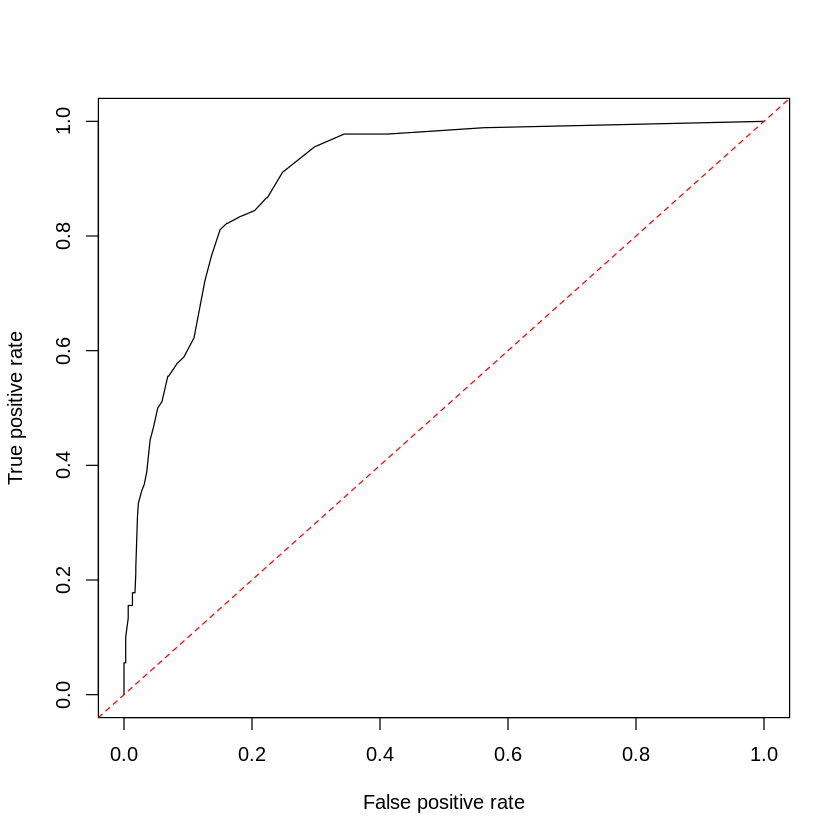

In [ ]:
#Create prediction object
knn_pred2 <- prediction(knn_probs, y_test)

#Performance object
knn_perf2 <- performance(knn_pred2, "tpr", "fpr")

# Plot
plot(knn_perf2)

# Add a diagonal reference line
abline(a = 0, b = 1, col = "red", lty = 2)

In [ ]:
# AUC
knn_auc_perf <- performance(knn_pred2, measure = "auc")
knn_auc2 <- knn_auc_perf@y.values[[1]]
knn_auc2

[1] 0.9019982

### Random forest model

In [ ]:
install.packages("randomForest")
library(randomForest)

# Set seed
set.seed(42)

# Train model
model_rf2 <- randomForest(x = x_train,
                         y = y_train,
                         ntree = 2000)

model_rf2

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




Call:
 randomForest(x = x_train, y = y_train, ntree = 2000) 
               Type of random forest: classification
                     Number of trees: 2000
No. of variables tried at each split: 2

        OOB estimate of  error rate: 8.89%
Confusion matrix:
      no yes class.error
no  2817  73  0.02525952
yes  216 145  0.59833795

In [ ]:
# make predictions for yes/positive class
pred_rf2 <- predict(model_rf2, x_test, type="prob")[, 2]

# changing probabilities
conf_pred_rf2 <- ifelse(pred_rf2 > 0.5, "yes", "no")

# confusion matrix
table(y_test, conf_pred_rf2)

      conf_pred_rf2
y_test  no yes
   no  735  24
   yes  56  34

In [ ]:
# Confusion Matrix
conf_matrix_rf2 <- confusionMatrix(as.factor(conf_pred_rf2), y_test, positive = "yes")
conf_matrix_rf2

# Extract Precision, Recall, and F1-score
precision_rf2 <- conf_matrix_rf2$byClass["Precision"]
recall_rf2 <- conf_matrix_rf2$byClass["Recall"]
f1_score_rf2 <- conf_matrix_rf2$byClass["F1"]

# Print results
precision_rf2
recall_rf2
f1_score_rf2

Confusion Matrix and Statistics

          Reference
Prediction  no yes
       no  735  56
       yes  24  34
                                          
               Accuracy : 0.9058          
                 95% CI : (0.8841, 0.9246)
    No Information Rate : 0.894           
    P-Value [Acc > NIR] : 0.1442752       
                                          
                  Kappa : 0.4105          
                                          
 Mcnemar's Test P-Value : 0.0005284       
                                          
            Sensitivity : 0.37778         
            Specificity : 0.96838         
         Pos Pred Value : 0.58621         
         Neg Pred Value : 0.92920         
             Prevalence : 0.10601         
         Detection Rate : 0.04005         
   Detection Prevalence : 0.06832         
      Balanced Accuracy : 0.67308         
                                          
       'Positive' Class : yes             
                              

Precision 
0.5862069

Recall 
0.3777778

F1 
0.4594595

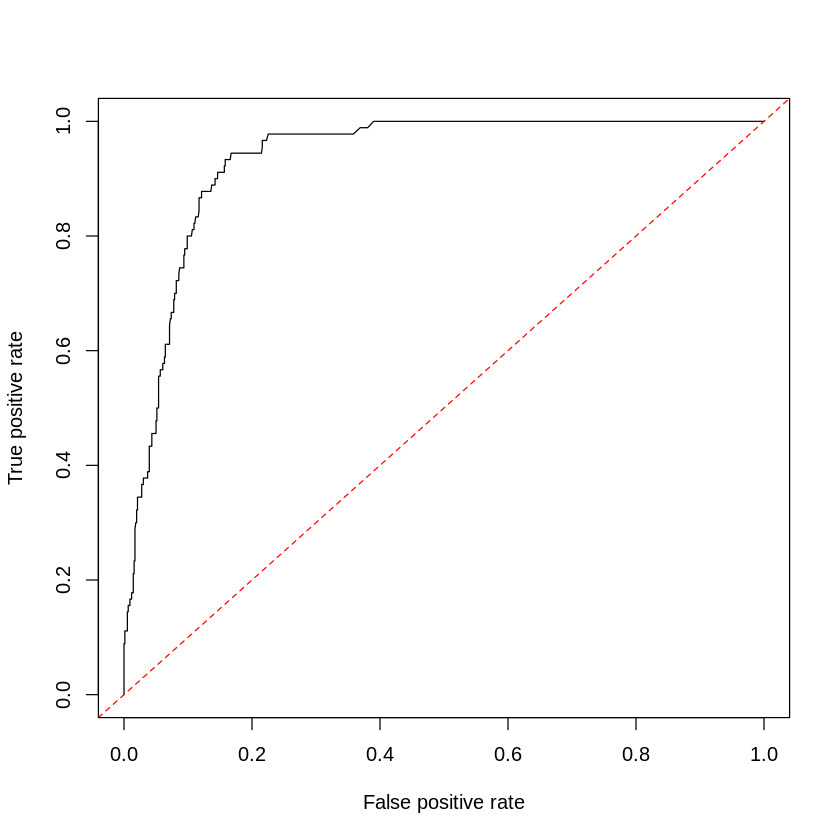

In [ ]:
#Create prediction object
rf_pred2 <- prediction(pred_rf2, y_test)

#Performance object
rf_perf2 <- performance(rf_pred2, "tpr", "fpr")

# Plot
plot(rf_perf2)
# Add a diagonal reference line
abline(a = 0, b = 1, col = "red", lty = 2)

In [ ]:
# AUC
rf_auc_perf <- performance(rf_pred2, measure = "auc")
rf_auc2 <- rf_auc_perf@y.values[[1]]
rf_auc2

[1] 0.9336115

### Feature selected ROC plot

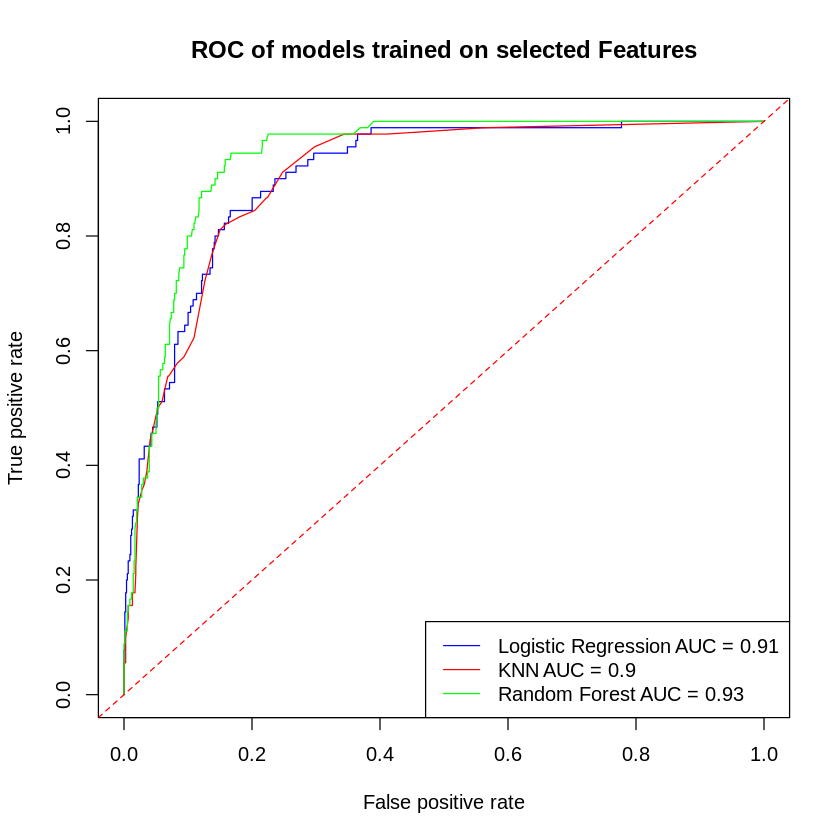

In [ ]:
# Plot all of the loss curves
plot(glm_perf, col="blue", main = "ROC of models trained on selected Features")
plot(knn_perf2, add = TRUE, col="red")
plot(rf_perf2, add = TRUE, col="green")
legend("bottomright",
       legend = c(paste("Logistic Regression", "AUC =", round(glm_auc, 2)), paste("KNN", "AUC =", round(knn_auc2, 2)), paste("Random Forest", "AUC =", round(rf_auc2, 2))),
       col = c("blue", "red", "green"),
       lty = 1)

# Add a diagonal reference line
abline(a = 0, b = 1, col = "red", lty = 2)

### Original ROC Plot

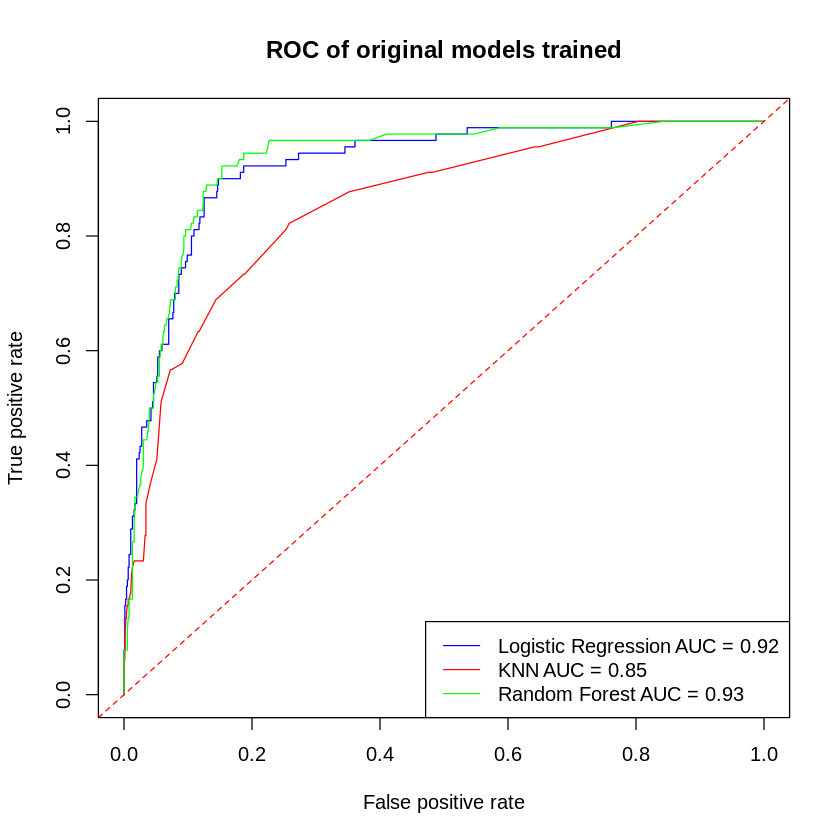

In [ ]:
# Plot all of the loss curves
plot(perf, col="blue", main = "ROC of original models trained")
plot(knn_perf, add = TRUE, col="red")
plot(rf_perf, add = TRUE, col="green")
legend("bottomright",
       legend = c(paste("Logistic Regression", "AUC =", round(auc, 2)), paste("KNN", "AUC =", round(knn_auc, 2)), paste("Random Forest", "AUC =", round(rf_auc, 2))),
       col = c("blue", "red", "green"),
       lty = 1)

# Add a diagonal reference line
abline(a = 0, b = 1, col = "red", lty = 2)

In [ ]:
f1_score_glm1

F1 
0.5419355

In [ ]:
f1_score_glm2

F1 
0.4714286

In [ ]:
f1_score_knn1

F1 
0.1616162

In [ ]:
f1_score_knn2

F1 
0.2477876

In [ ]:
f1_score_rf

F1 
0.4615385

In [ ]:
f1_score_rf2

F1 
0.4594595

glm2 and rf2 have the fewest variables and the best f1-scores. so lets compare precision and recall.

In [ ]:
#glm2
print("Logistic Regression 2")
precision_glm2
recall_glm2
f1_score_glm2

[1] "Logistic Regression 2"


Precision 
     0.66

Recall 
0.3666667

F1 
0.4714286

In [ ]:
#rf2
print("Random Forest 2")
precision_rf2
recall_rf2
f1_score_rf2

[1] "Random Forest 2"


Precision 
0.5862069

Recall 
0.3777778

F1 
0.4594595